In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scienceplots  # registers the 'science' / 'ieee' styles
from collections import Counter
import matplotlib.patches as mpatches
import os
import seaborn as sns

# ---- Global plot styling ----
# Fixed, ordered color vector shared by every plot below except scatter_time_performance
# (which keeps its own long-standing manual palette). Colors are used in order: a plot
# that needs 2 colors gets the first 2, one that needs 12 gets all 12, and so on - edit
# this list directly to change what every plot uses. The defaults below are sampled
# once from 'cividis' (perceptually uniform, so monotonic in greyscale) at 12 evenly
# spaced points, which makes them colorblind-safe and print/greyscale-safe as a set.
COLOR_PALETTE = [
     '#2b83ba', '#fdae61', '#abdda4','#d7191c','#ffffbf'
]

#d7191c
#fdae61
#ffffbf
#abdda4
#2b83ba

# Uniform font sizes applied to every plot's axis labels, tick labels, and legend below.
TITLE_FONT_SIZE = 12         # plot title
FONT_SIZE_LABEL = 12          # xlabel / ylabel
FONT_SIZE_TICK = 12           # x/y tick labels
FONT_SIZE_LEGEND = 12         # legend entries
FONT_SIZE_LEGEND_TITLE = 12   # legend title

def get_colors(n):
    """First n colors from COLOR_PALETTE, in order (cycles if n exceeds its length)."""
    return [COLOR_PALETTE[i % len(COLOR_PALETTE)] for i in range(n)]


all_policy_colors = [
    '#1f78b4', "#50c2ff", '#b2df8a', '#33a02c', '#fb9a99', 
    '#e31a1c', '#fdbf6f', '#ff7f00', '#cab2d6', '#6a3d9a',
     "#e704eb", "#000000"
]

#plt.style.use(['science', 'ieee'])
plt.style.use(['science', 'muted', 'no-latex'])

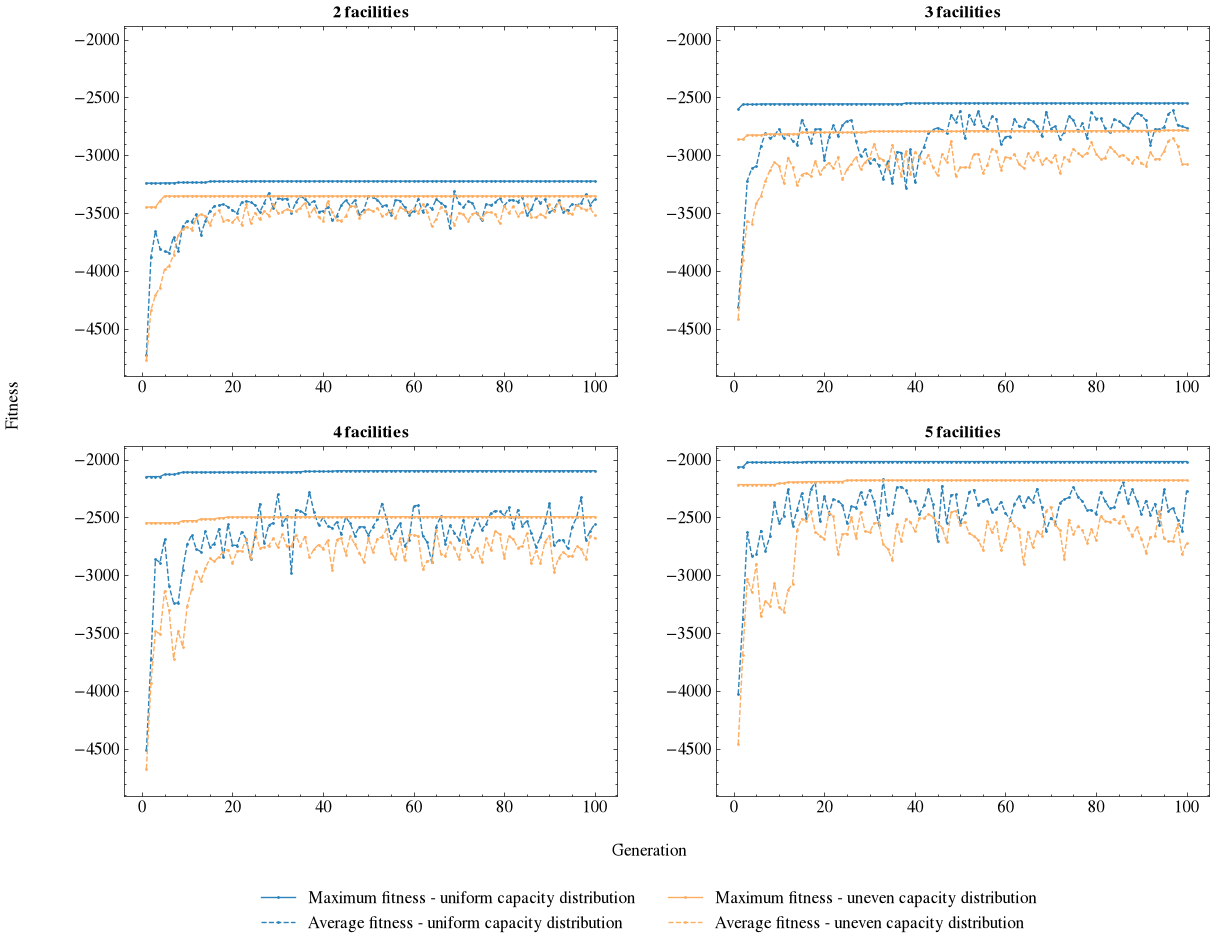

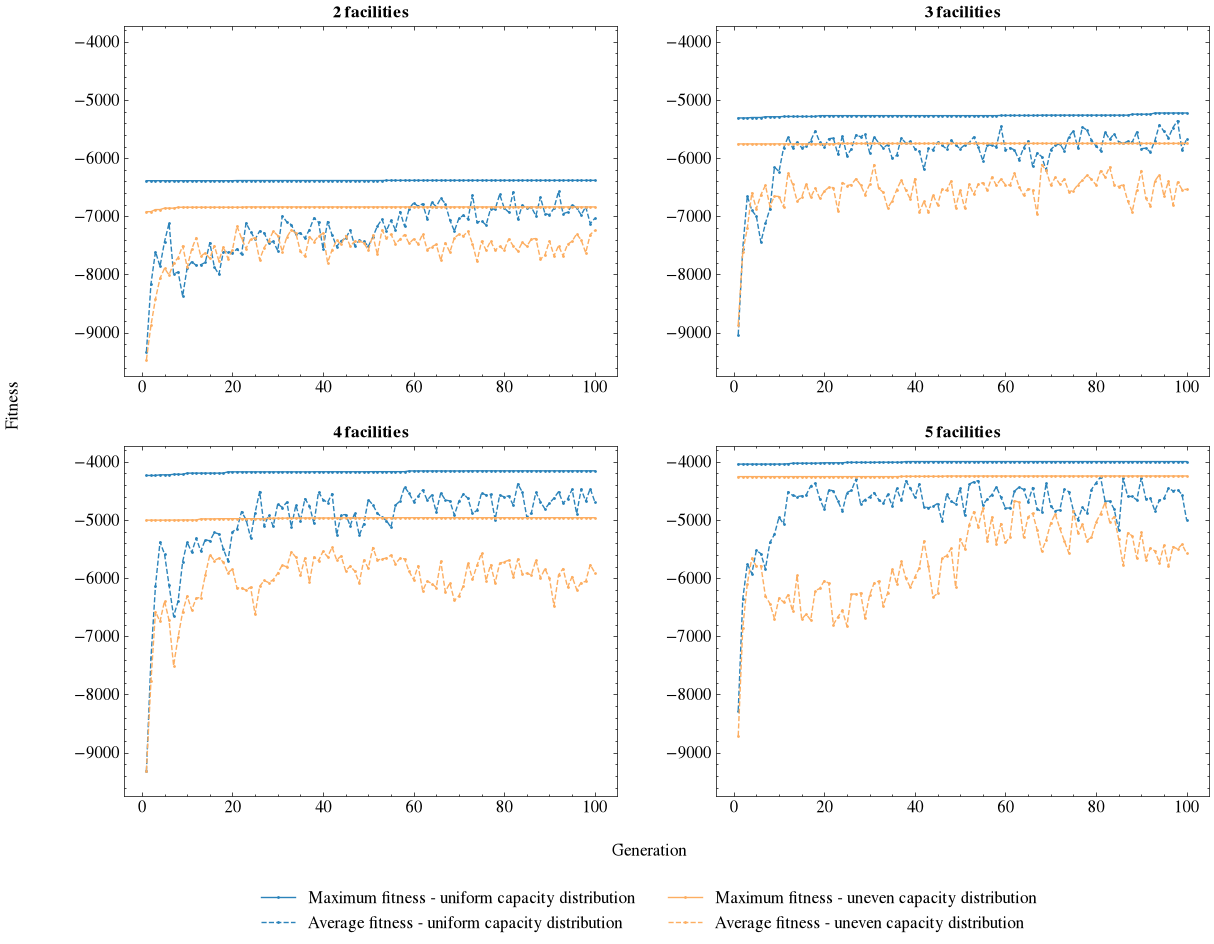

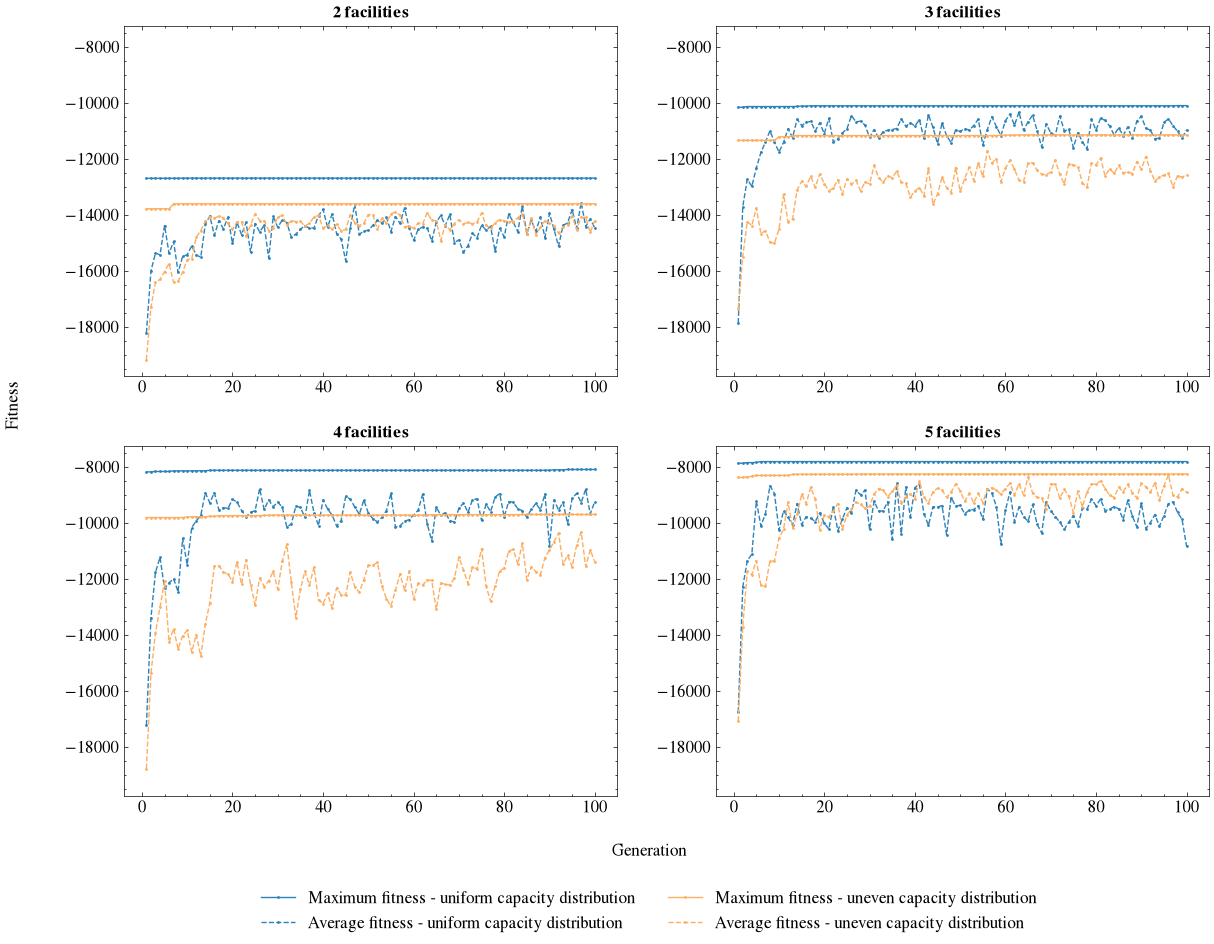

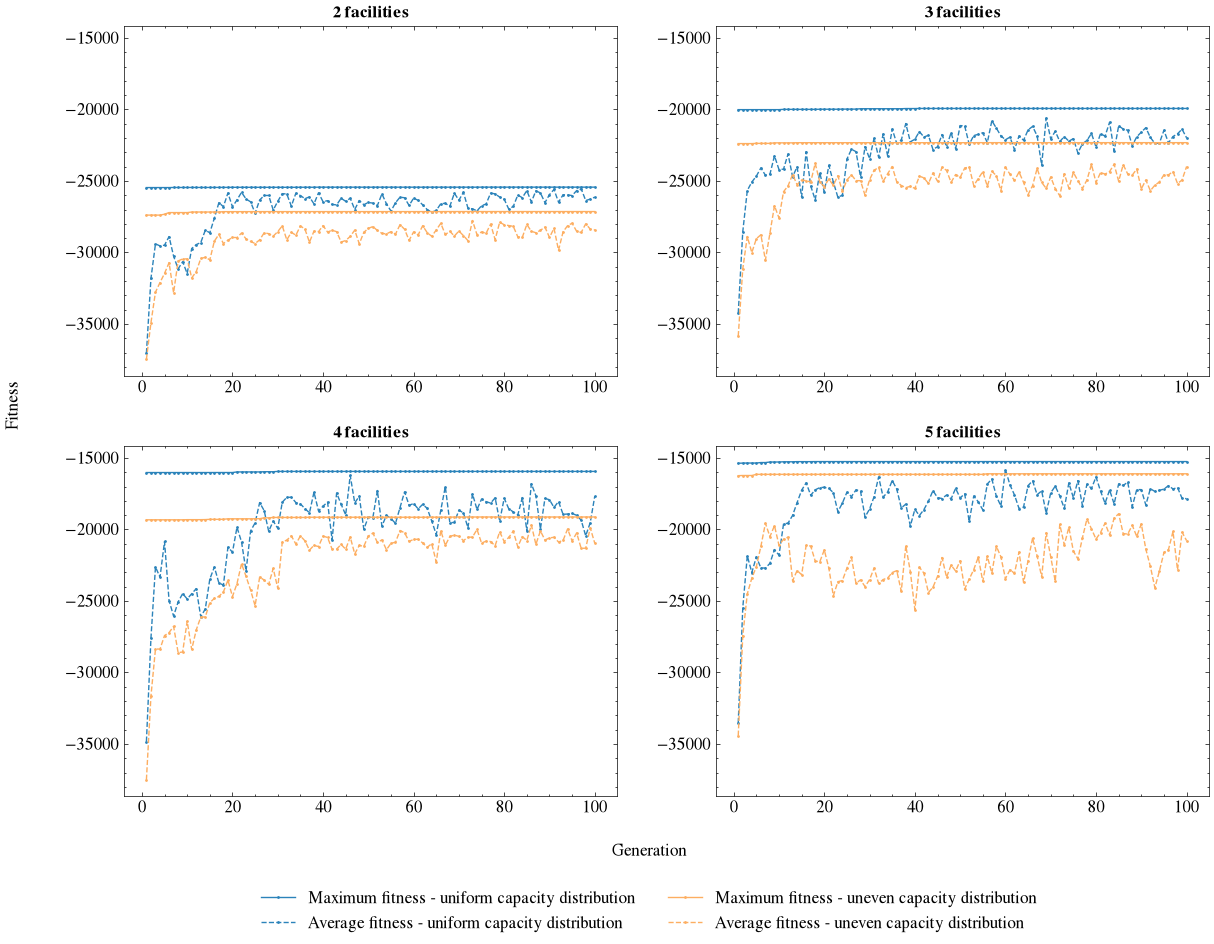

In [11]:
def gp_plot(num_customers):

    # Requisitos para exportar em PDF
    plt.rcParams['pdf.fonttype'] = 42
    plt.rcParams['ps.fonttype'] = 42

    # Cria o gráfico de evolução
    fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharex=True, sharey=True)

    num_warehouses_options = [2, 3, 4, 5]
    capacity_distribution_options = ['uniform', 'uneven']

    colors = get_colors(len(capacity_distribution_options))

    for ax, num_warehouses in zip(axes.flatten(), num_warehouses_options):
        for capacity_distribution in capacity_distribution_options:
            df = pd.read_csv(f'training/genetic_programming_training/gp_w_{num_warehouses}_c_{num_customers}_d_{capacity_distribution}_best_individuals.csv')
            grouped_df = df.groupby('generation').agg({'max_fitness': 'mean', 'avg_fitness': 'mean'}).reset_index()
            ax.plot(grouped_df['generation'], grouped_df['max_fitness'], marker='o', label=f'Maximum fitness - {capacity_distribution} capacity distribution', linestyle='solid', markersize=1, linewidth=1, color=colors[capacity_distribution_options.index(capacity_distribution)])
            ax.plot(grouped_df['generation'], grouped_df['avg_fitness'], marker='o', label=f'Average fitness - {capacity_distribution} capacity distribution', linestyle='dashed', markersize=1, linewidth=1, color=colors[capacity_distribution_options.index(capacity_distribution)])
        
        ax.set_title(f'{num_warehouses} facilities', fontweight='bold')
        ax.grid(False)
        ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))
        ax.set_xticks([0, 20, 40, 60, 80, 100])
        ax.tick_params(axis='both', labelsize=FONT_SIZE_TICK, labelbottom=True, labelleft=True)

    # Set common labels
    fig.text(0.5, 0.05, 'Generation', ha='center', fontsize=FONT_SIZE_LABEL)
    fig.text(0.04, 0.5, 'Fitness', va='center', rotation='vertical', fontsize=FONT_SIZE_LABEL)

    # Add a shared legend
    handles, labels = ax.get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 0.03), ncol=2, fontsize=FONT_SIZE_LEGEND)

    # Store the plot in a jpg file
    plt.savefig(f'training/genetic_programming_training/plots/gp_c_{num_customers}.pdf', dpi=600, bbox_inches='tight')

    # Exibe o gráfico
    #plt.show()

for num_customers in num_customers_options:
    gp_plot(num_customers)

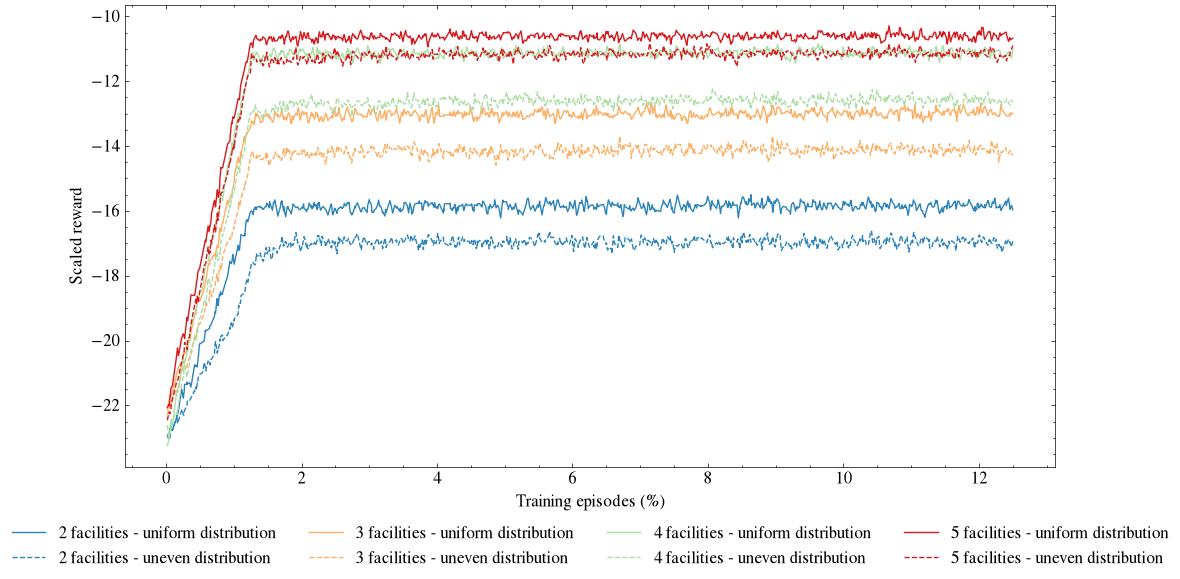

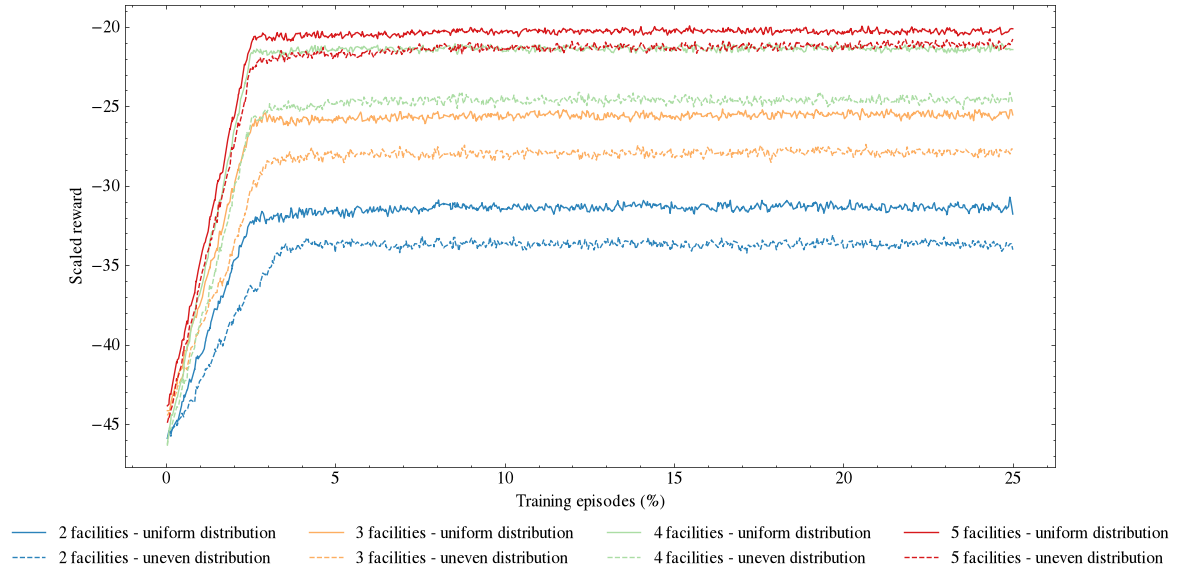

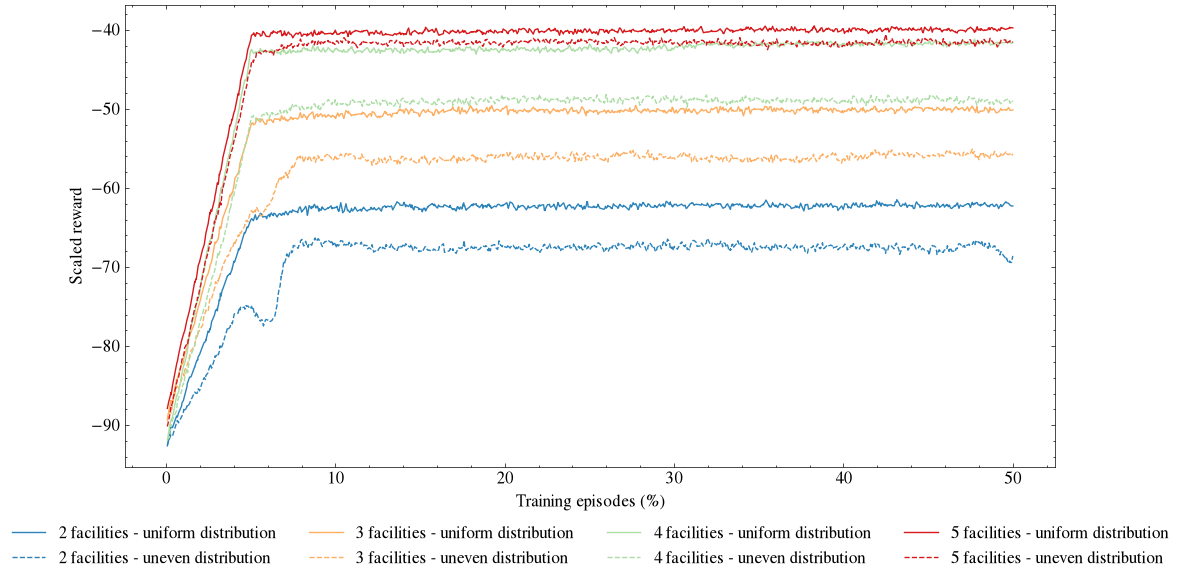

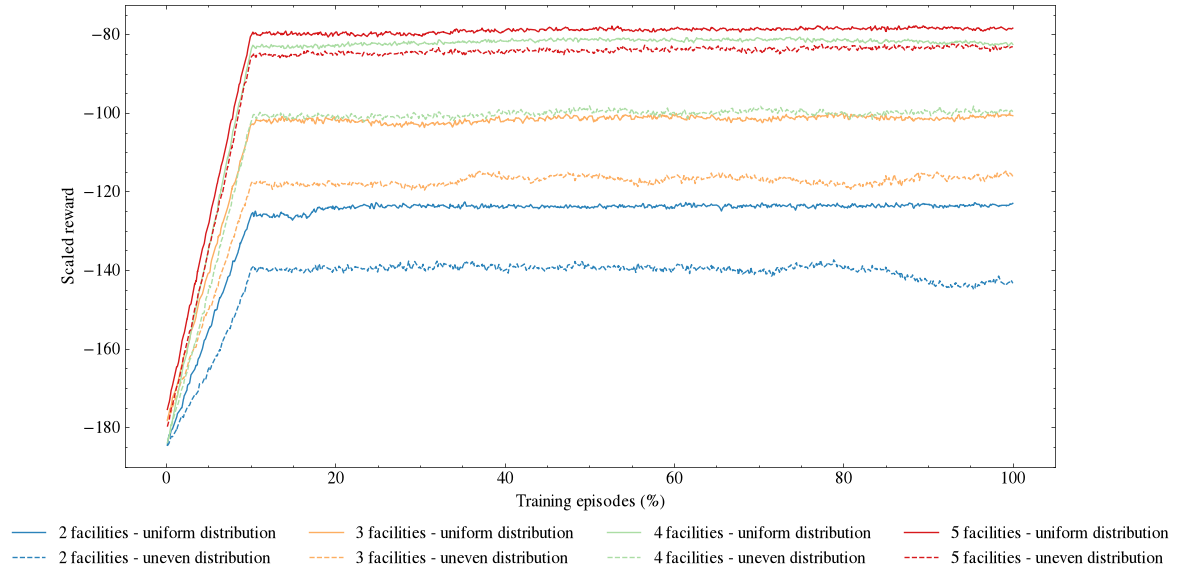

In [12]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import glob

# Warehouse count -> color (COLOR_PALETTE) and capacity distribution -> linestyle, defined
# below once num_warehouses_options is available.

data = {}

num_warehouses_options = [2, 3, 4, 5]
num_customers_options = [50, 100, 200, 400]
capacity_distribution_options = ["uniform", "uneven"]

SMOOTHING = 0  # 0 = raw reward (no smoothing), up to 0.99 = heaviest smoothing (TensorBoard-style EMA)

# Read files and extract relevant data
for num_warehouses in num_warehouses_options:
    for num_customers in num_customers_options:

        n_steps = num_customers * 50_000  # Assuming n_steps is 10 times the number of customers
        for capacity_distribution in capacity_distribution_options:
            filename = f"training/deep_q_networks_training/reward_evolution/DQN_w_{num_warehouses}_c_{num_customers}_d_{capacity_distribution}_DQN_1.csv"
            
            df = pd.read_csv(filename)
            df = df.sort_values(by='Step')  # Ensure data is sorted by step
            
            if num_customers not in data:
                data[num_customers] = []
            
            data[num_customers].append({
                "warehouses": num_warehouses,
                "distribution": capacity_distribution,
                "df": df
            })

# Warehouse count -> color, capacity distribution -> linestyle (colorblind- and
# greyscale-safe: distinguishable by hue AND by dash pattern)
warehouse_colors = dict(zip(num_warehouses_options, get_colors(len(num_warehouses_options))))
distribution_linestyles = {"uniform": "-", "uneven": "--"}

# Plot each graph for different customer counts
for num_customers, datasets in data.items():
    plt.figure(figsize=(12, 6))
    
    for entry in datasets:
        color = warehouse_colors[entry["warehouses"]]
        linestyle = distribution_linestyles[entry["distribution"]]

        smoothed_values = smooth_curve(entry["df"]["Value"].to_numpy(), SMOOTHING)

        plt.plot(entry["df"]["Step"] / n_steps * 100, smoothed_values,
                 label=f'{entry["warehouses"]} facilities - {entry["distribution"]} distribution',
                 color=color, linestyle=linestyle)
    plt.xlabel("Training episodes (%)", fontsize=FONT_SIZE_LABEL)
    plt.ylabel("Scaled reward", fontsize=FONT_SIZE_LABEL)
    plt.xticks(fontsize=FONT_SIZE_TICK)
    plt.yticks(fontsize=FONT_SIZE_TICK)
    plt.legend(loc='lower center', bbox_to_anchor=(0.5, -0.25), ncol=4, fontsize=FONT_SIZE_LEGEND)
    plt.grid(False)

    # Save figure
    plt.savefig(f"training/deep_q_networks_training/plots/dqn_reward_evolution_orders_{num_customers}.pdf", bbox_inches='tight', dpi=600)

    #plt.show()


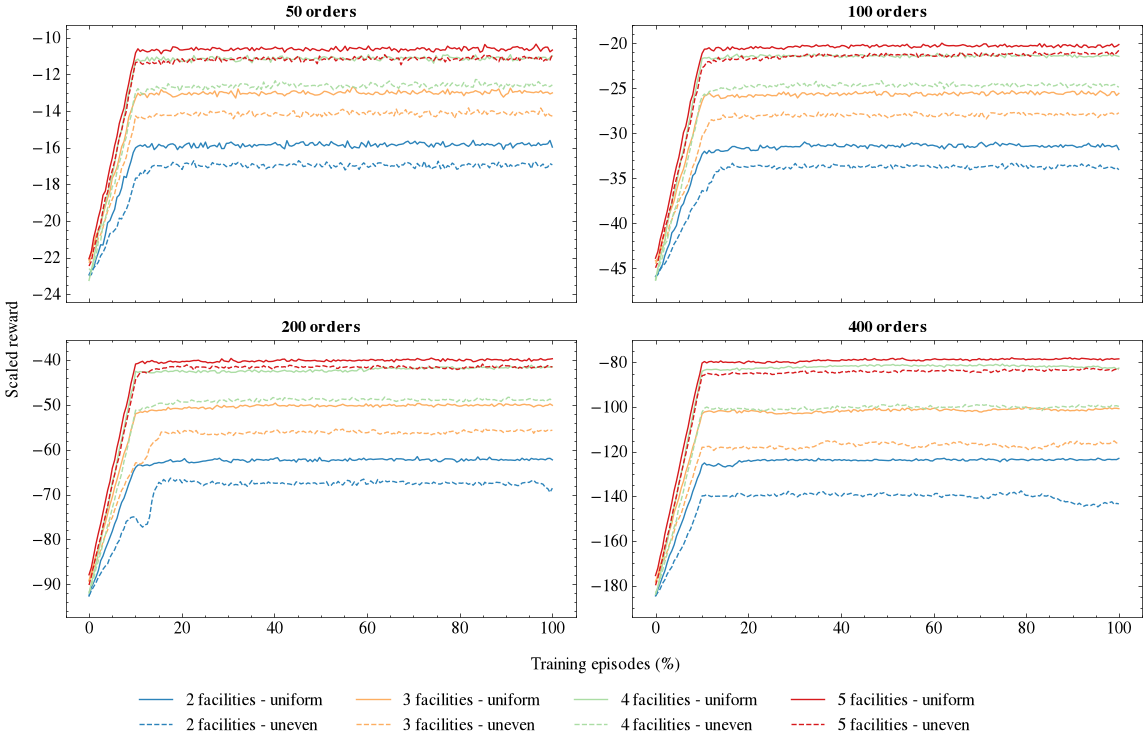

In [23]:
# Build pooled curves for one single figure
curves = {}

num_warehouses_options = [2, 3, 4, 5]
num_customers_options = [50, 100, 200, 400]
capacity_distribution_options = ["uniform", "uneven"]

SMOOTHING = 0

for num_warehouses in num_warehouses_options:
    for num_customers in num_customers_options:
        n_steps = num_customers * 50_000
        for capacity_distribution in capacity_distribution_options:
            filename = (
                f"training/deep_q_networks_training/reward_evolution/"
                f"DQN_w_{num_warehouses}_c_{num_customers}_d_{capacity_distribution}_DQN_1.csv"
            )

            df = pd.read_csv(filename).sort_values(by="Step")
            x = df["Step"].to_numpy() / n_steps * 100
            y = np.array(smooth_curve(df["Value"].to_numpy(), SMOOTHING))

            x_grid = np.linspace(0, 100, 200)
            y_interp = np.interp(x_grid, x, y)

            curves.setdefault((num_customers, num_warehouses, capacity_distribution), []).append(y_interp)

# Same color code as the cell above
warehouse_colors = dict(zip(num_warehouses_options, get_colors(len(num_warehouses_options))))
distribution_linestyles = {"uniform": "-", "uneven": "--"}

fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True, sharey=False)
axes = np.atleast_1d(axes).flatten()
x_grid = np.linspace(0, 100, 200)

for ax, num_customers in zip(axes, num_customers_options):
    y_min, y_max = np.inf, -np.inf

    for num_warehouses in num_warehouses_options:
        for capacity_distribution in capacity_distribution_options:
            ys = curves.get((num_customers, num_warehouses, capacity_distribution), [])
            if not ys:
                continue

            y_mean = np.mean(np.vstack(ys), axis=0)
            y_min = min(y_min, np.min(y_mean))
            y_max = max(y_max, np.max(y_mean))

            ax.plot(
                x_grid,
                y_mean,
                label=f"{num_warehouses} facilities - {capacity_distribution}",
                color=warehouse_colors[num_warehouses],
                linestyle=distribution_linestyles[capacity_distribution],
            )

    ax.set_title(f"{num_customers} orders", fontweight="bold")
    ax.grid(False)
    ax.tick_params(axis="both", labelsize=FONT_SIZE_TICK)
    ax.set_ylim(y_min * 1.05, y_max * 0.9)

fig.text(0.54, 0.10, "Training episodes (%)", ha="center", fontsize=FONT_SIZE_LABEL)
fig.text(0.04, 0.5, "Scaled reward", va="center", rotation="vertical", fontsize=FONT_SIZE_LABEL)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles=handles,
    loc="lower center",
    bbox_to_anchor=(0.5, 0.00),
    ncol=4,
    fontsize=FONT_SIZE_LEGEND,
    title_fontsize=FONT_SIZE_LEGEND_TITLE,
)

plt.tight_layout(rect=[0.05, 0.12, 1, 0.95])
plt.savefig(
    "training/deep_q_networks_training/plots/dqn_reward_evolution_all.pdf",
    bbox_inches="tight",
    dpi=600,
)
plt.show()


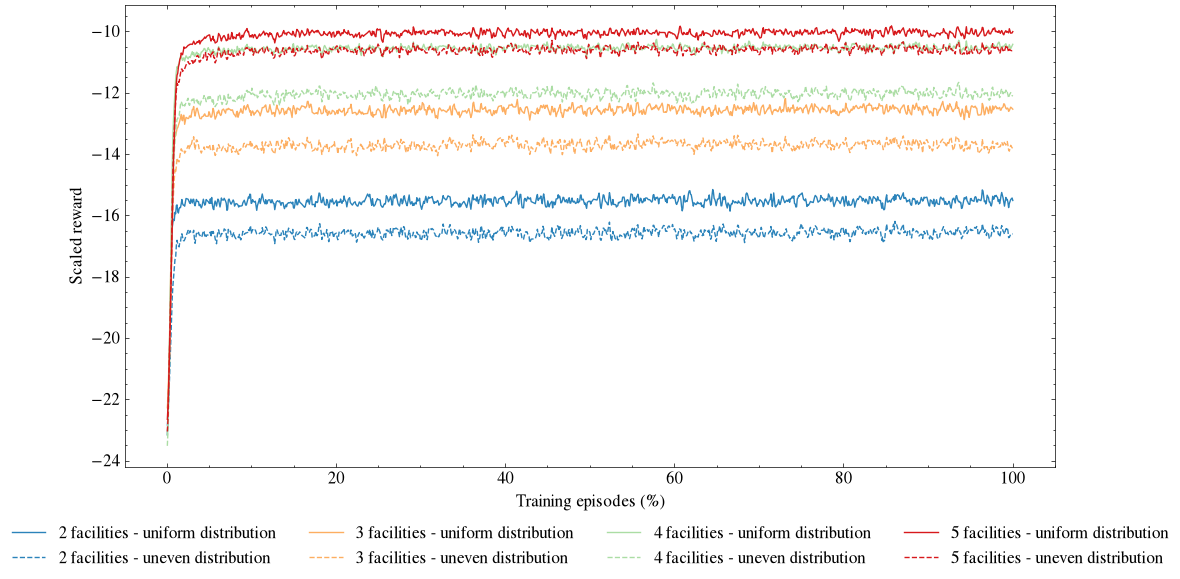

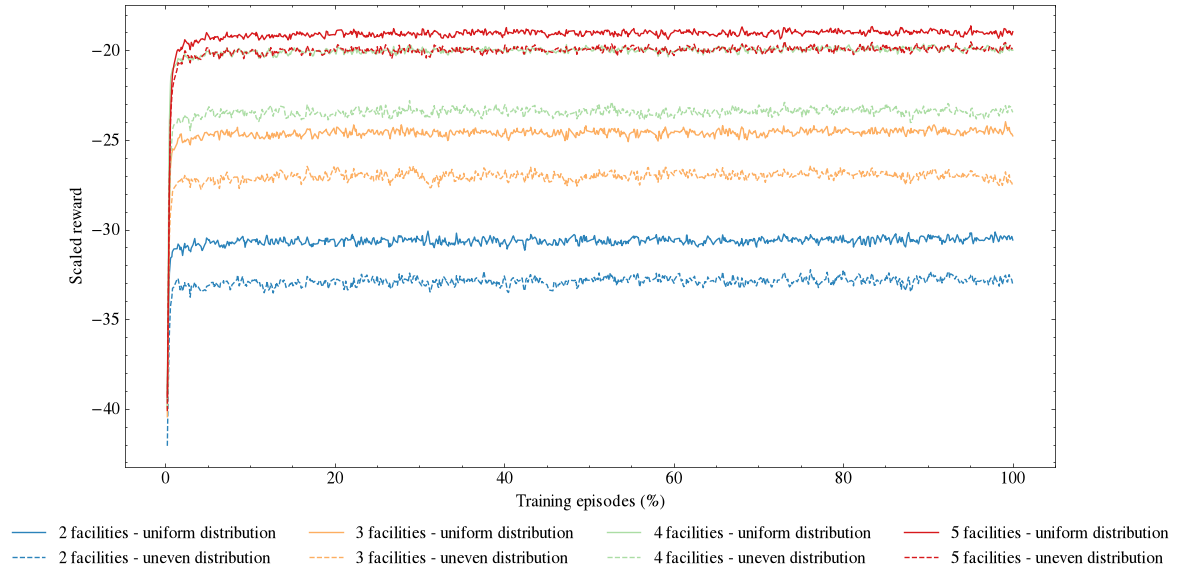

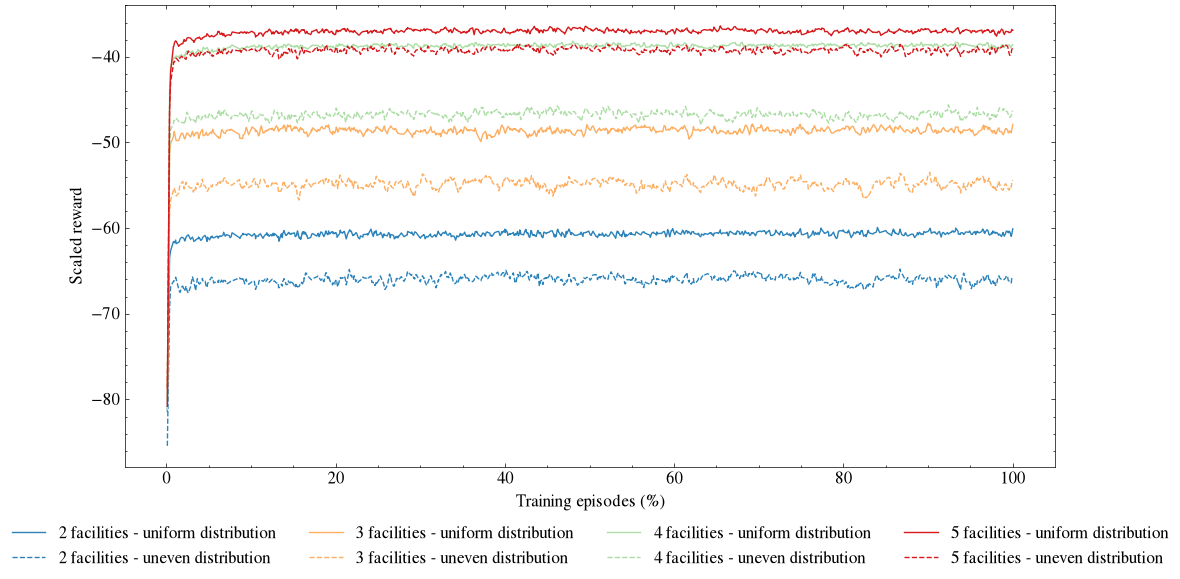

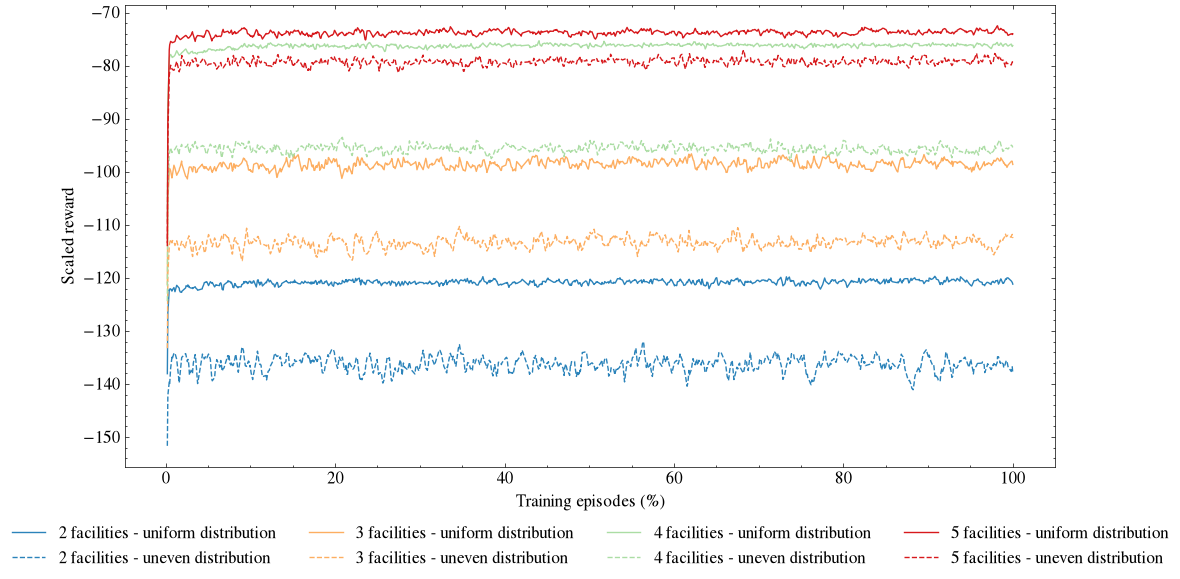

In [13]:
data = {}

num_warehouses_options = [2, 3, 4, 5]
num_customers_options = [50, 100, 200, 400]
capacity_distribution_options = ["uniform", "uneven"]

SMOOTHING = 0  # 0 = raw reward (no smoothing), up to 0.99 = heaviest smoothing (TensorBoard-style EMA)

# Read files and extract relevant data
for num_warehouses in num_warehouses_options:
    for num_customers in num_customers_options:

        n_steps = num_customers * 50_000  # Assuming n_steps is 10 times the number of customers
        for capacity_distribution in capacity_distribution_options:
            filename = f"training/proximal_policy_optimization_training/reward_evolution/PPO_w_{num_warehouses}_c_{num_customers}_d_{capacity_distribution}_MaskablePPO_1.csv"
            
            df = pd.read_csv(filename)
            df = df.sort_values(by='Step')  # Ensure data is sorted by step
            
            if num_customers not in data:
                data[num_customers] = []
            
            data[num_customers].append({
                "warehouses": num_warehouses,
                "distribution": capacity_distribution,
                "df": df
            })

# Warehouse count -> color, capacity distribution -> linestyle (colorblind- and
# greyscale-safe: distinguishable by hue AND by dash pattern)
warehouse_colors = dict(zip(num_warehouses_options, get_colors(len(num_warehouses_options))))
distribution_linestyles = {"uniform": "-", "uneven": "--"}

# Plot each graph for different customer counts
for num_customers, datasets in data.items():

    n_steps = num_customers * 50_000  # Assuming n_steps is 10 times the number of customers
    
    plt.figure(figsize=(12, 6))
    
    for entry in datasets:
        color = warehouse_colors[entry["warehouses"]]
        linestyle = distribution_linestyles[entry["distribution"]]

        smoothed_values = smooth_curve(entry["df"]["Value"].to_numpy(), SMOOTHING)

        plt.plot(entry["df"]["Step"] / n_steps * 100, smoothed_values,
                 label=f'{entry["warehouses"]} facilities - {entry["distribution"]} distribution',
                 color=color, linestyle=linestyle)
    plt.xlabel("Training episodes (%)", fontsize=FONT_SIZE_LABEL)
    plt.ylabel("Scaled reward", fontsize=FONT_SIZE_LABEL)
    plt.xticks(fontsize=FONT_SIZE_TICK)
    plt.yticks(fontsize=FONT_SIZE_TICK)
    plt.legend(loc='lower center', bbox_to_anchor=(0.5, -0.25), ncol=4, fontsize=FONT_SIZE_LEGEND)
    plt.grid(False)

    # Save figure
    plt.savefig(f"training/proximal_policy_optimization_training/plots/ppo_reward_evolution_orders_{num_customers}.pdf", bbox_inches='tight', dpi=600)

    #plt.show()

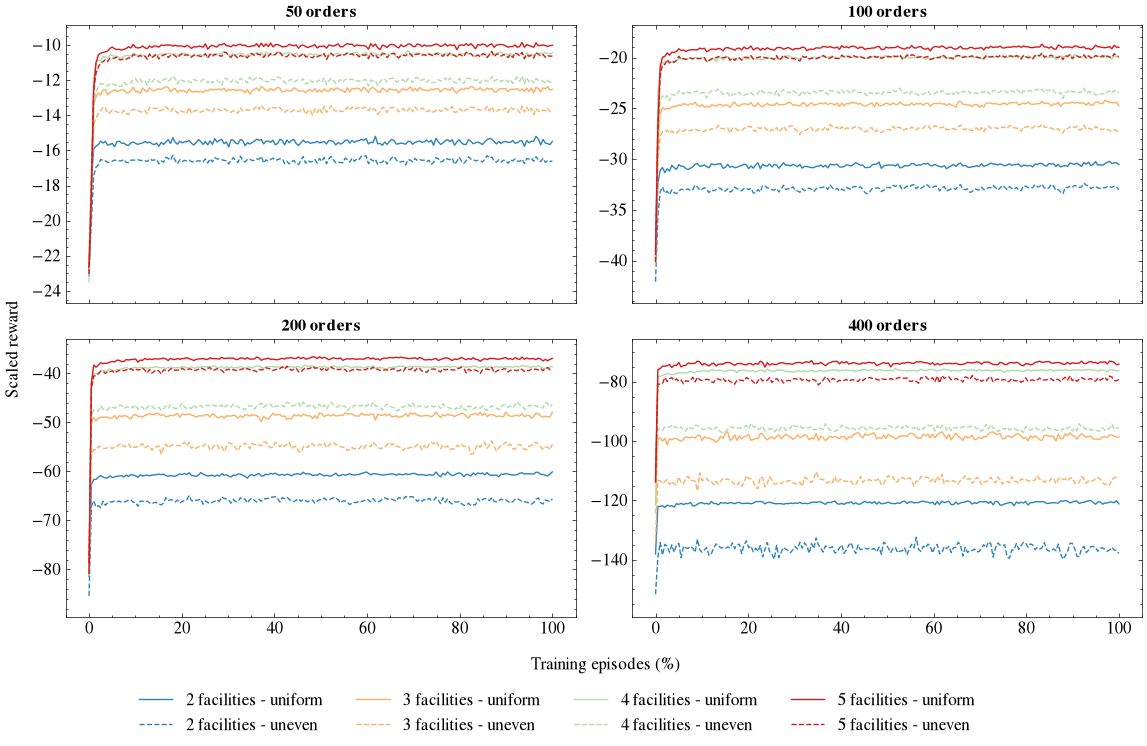

In [26]:
# Build pooled curves for one single figure
curves = {}

num_warehouses_options = [2, 3, 4, 5]
num_customers_options = [50, 100, 200, 400]
capacity_distribution_options = ["uniform", "uneven"]

SMOOTHING = 0

for num_warehouses in num_warehouses_options:
    for num_customers in num_customers_options:
        n_steps = num_customers * 50_000
        for capacity_distribution in capacity_distribution_options:
            filename = (
                f"training/proximal_policy_optimization_training/reward_evolution/"
                f"PPO_w_{num_warehouses}_c_{num_customers}_d_{capacity_distribution}_MaskablePPO_1.csv"
            )

            df = pd.read_csv(filename).sort_values(by="Step")
            x = df["Step"].to_numpy() / n_steps * 100
            y = np.array(smooth_curve(df["Value"].to_numpy(), SMOOTHING))

            x_grid = np.linspace(0, 100, 200)
            y_interp = np.interp(x_grid, x, y)

            curves.setdefault((num_customers, num_warehouses, capacity_distribution), []).append(y_interp)

# Same color code as the cell above
warehouse_colors = dict(zip(num_warehouses_options, get_colors(len(num_warehouses_options))))
distribution_linestyles = {"uniform": "-", "uneven": "--"}

fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True, sharey=False)
axes = np.atleast_1d(axes).flatten()
x_grid = np.linspace(0, 100, 200)

for ax, num_customers in zip(axes, num_customers_options):
    y_min, y_max = np.inf, -np.inf

    for num_warehouses in num_warehouses_options:
        for capacity_distribution in capacity_distribution_options:
            ys = curves.get((num_customers, num_warehouses, capacity_distribution), [])
            if not ys:
                continue

            y_mean = np.mean(np.vstack(ys), axis=0)
            y_min = min(y_min, np.min(y_mean))
            y_max = max(y_max, np.max(y_mean))

            ax.plot(
                x_grid,
                y_mean,
                label=f"{num_warehouses} facilities - {capacity_distribution}",
                color=warehouse_colors[num_warehouses],
                linestyle=distribution_linestyles[capacity_distribution],
            )

    ax.set_title(f"{num_customers} orders", fontweight="bold")
    ax.grid(False)
    ax.tick_params(axis="both", labelsize=FONT_SIZE_TICK)
    ax.set_ylim(y_min * 1.05, y_max * 0.9)

fig.text(0.54, 0.10, "Training episodes (%)", ha="center", fontsize=FONT_SIZE_LABEL)
fig.text(0.04, 0.5, "Scaled reward", va="center", rotation="vertical", fontsize=FONT_SIZE_LABEL)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles=handles,
    loc="lower center",
    bbox_to_anchor=(0.5, 0.00),
    ncol=4,
    fontsize=FONT_SIZE_LEGEND,
    title_fontsize=FONT_SIZE_LEGEND_TITLE,
)

plt.tight_layout(rect=[0.05, 0.12, 1, 0.95])
plt.savefig(
    "training/proximal_policy_optimization_training/plots/ppo_reward_evolution_all.pdf",
    bbox_inches="tight",
    dpi=600,
)
plt.show()

/var/folders/s2/6ttmr5ds0dd97ztz21jjzx540000gn/T/ipykernel_29798/846776945.py:7: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure(figsize=(10, 6))


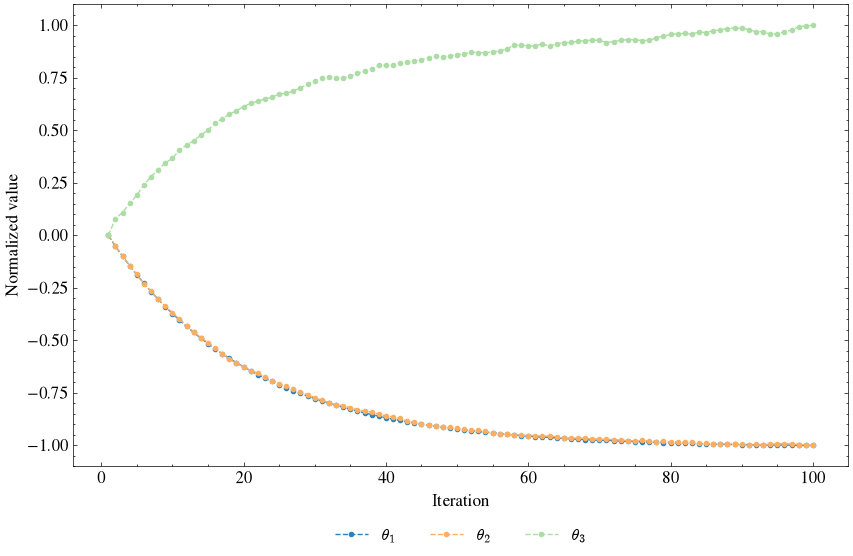

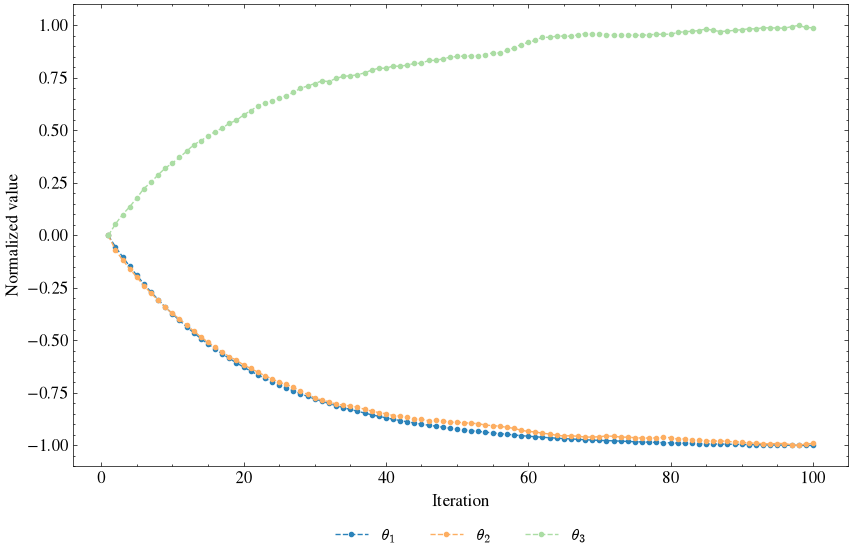

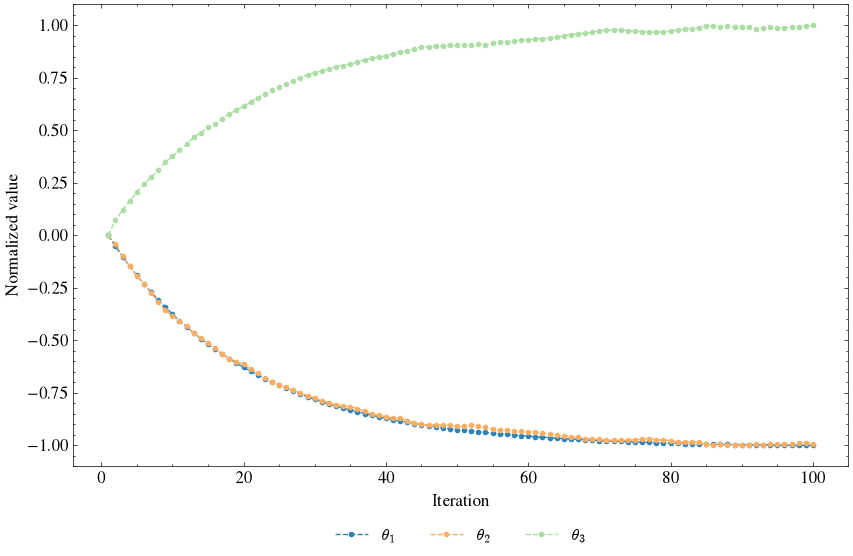

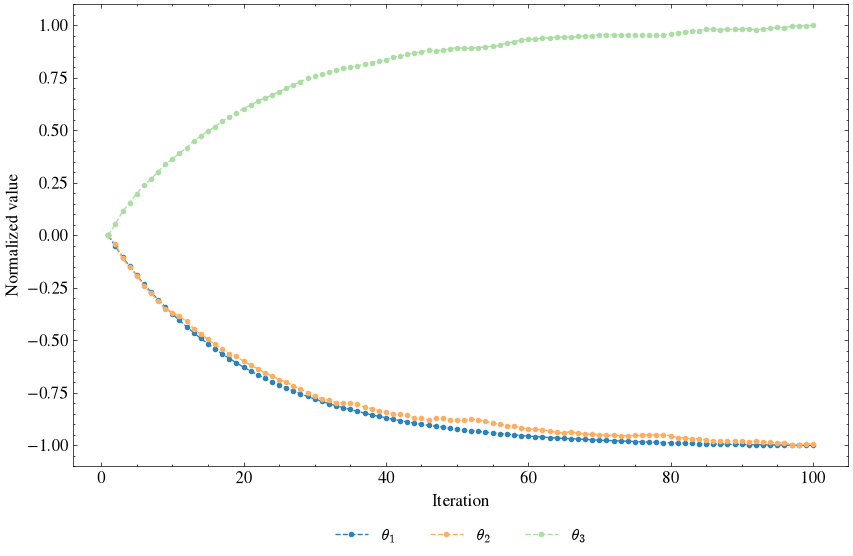

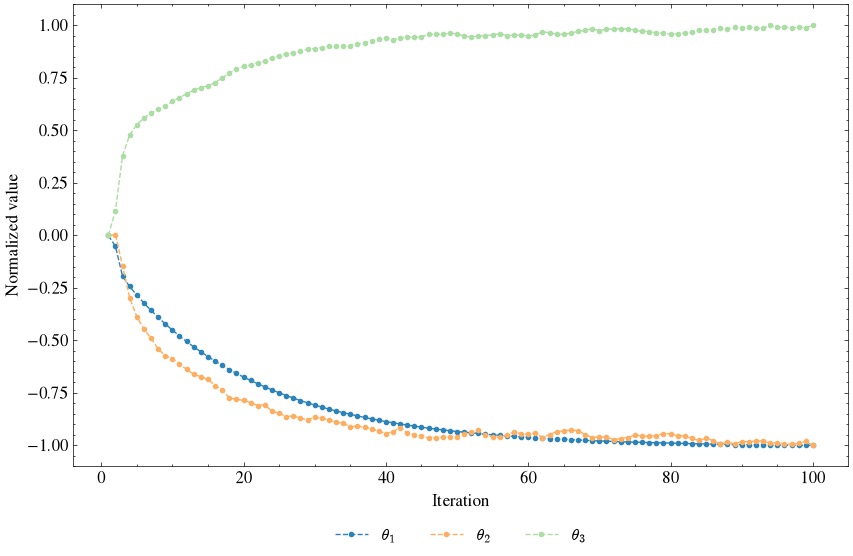

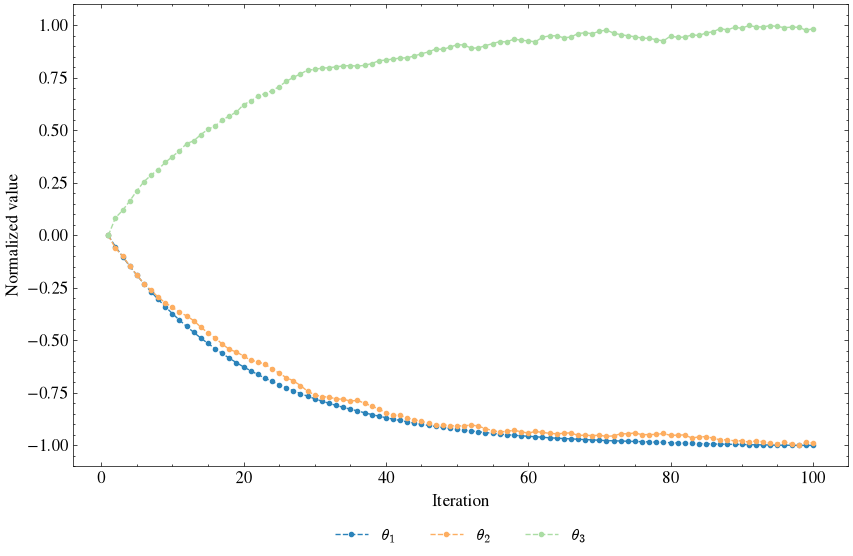

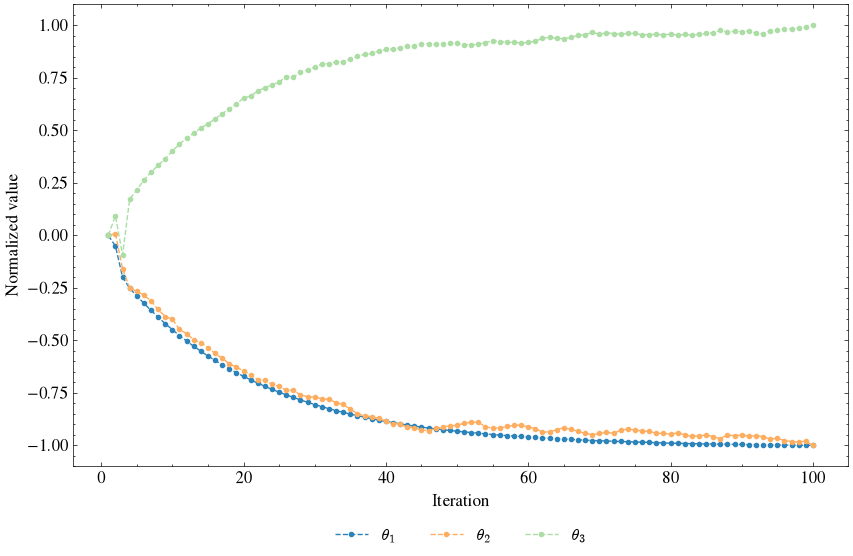

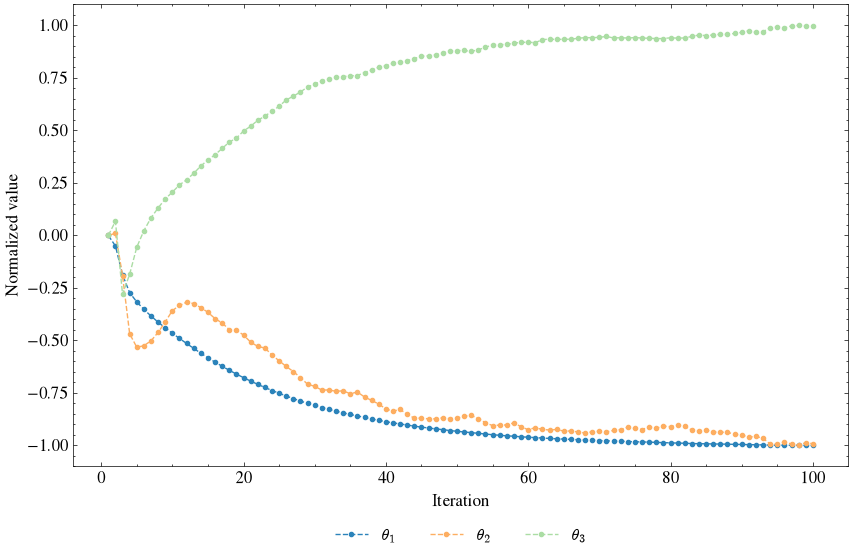

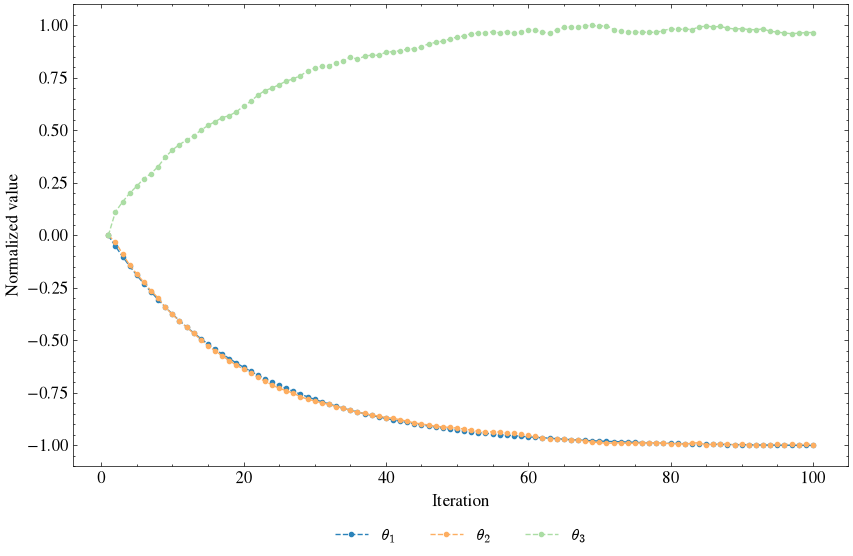

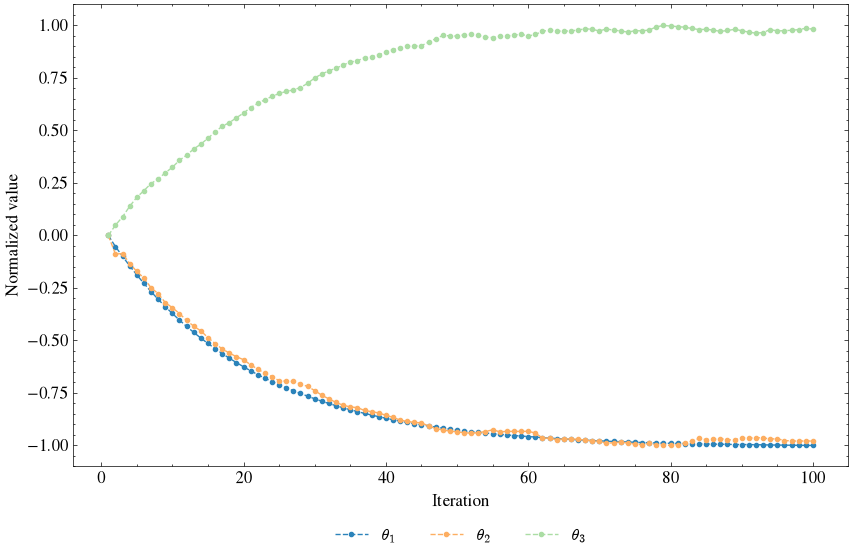

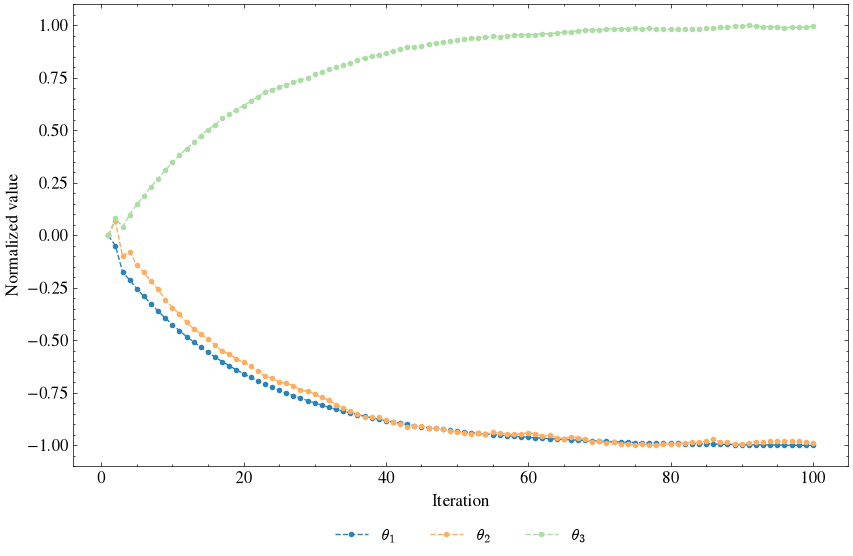

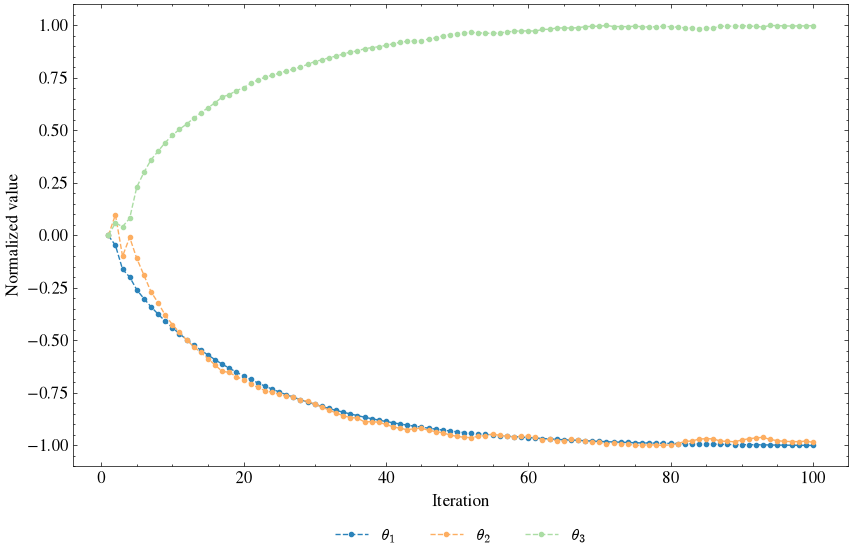

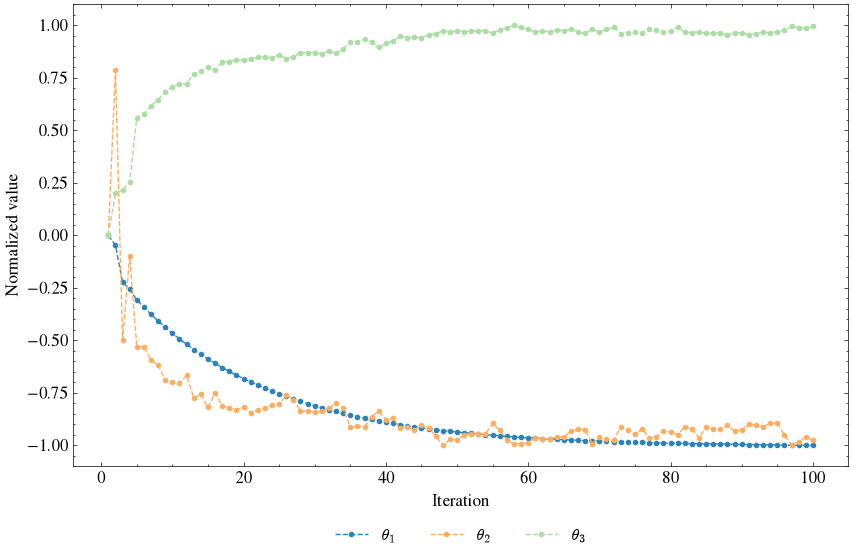

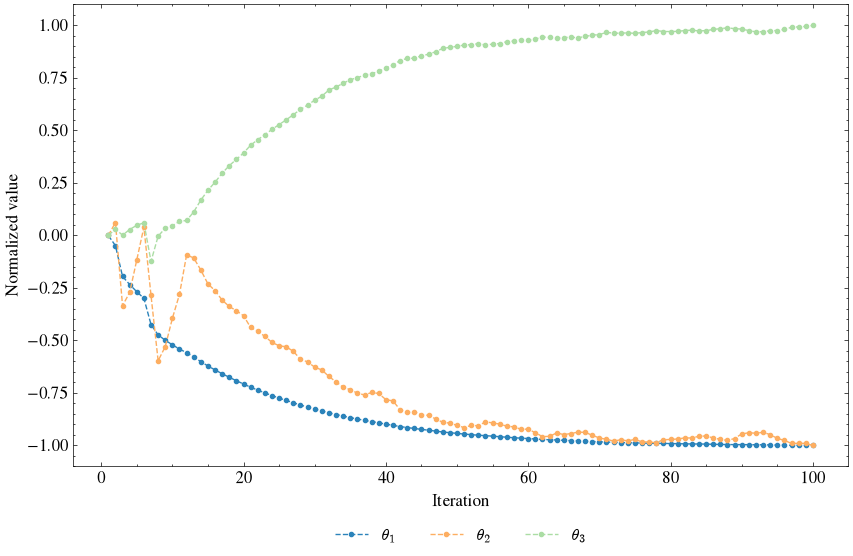

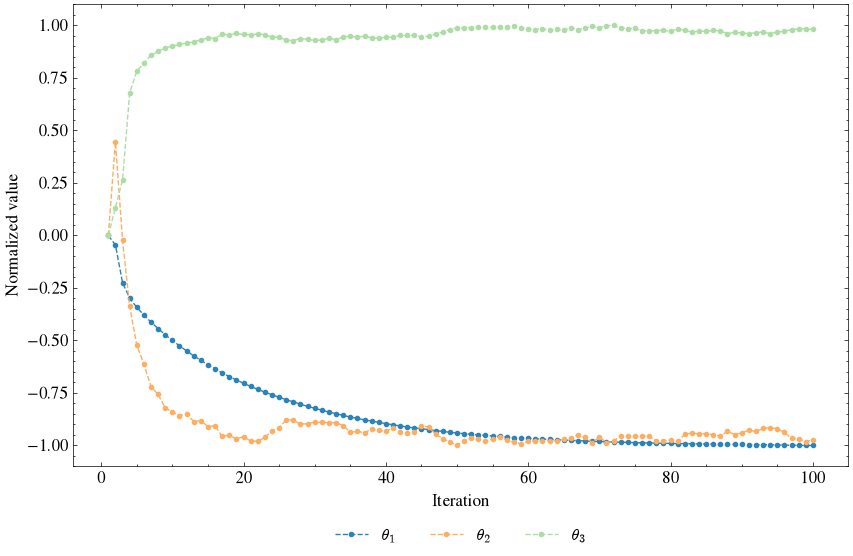

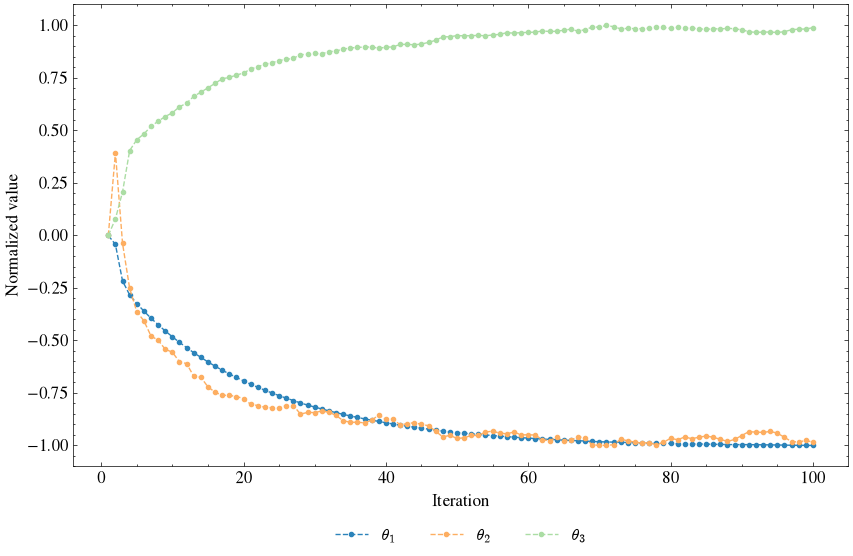

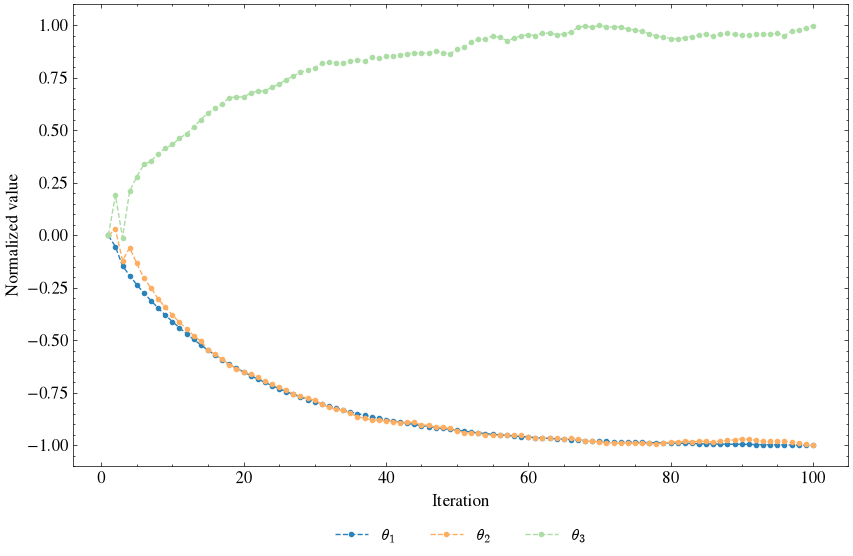

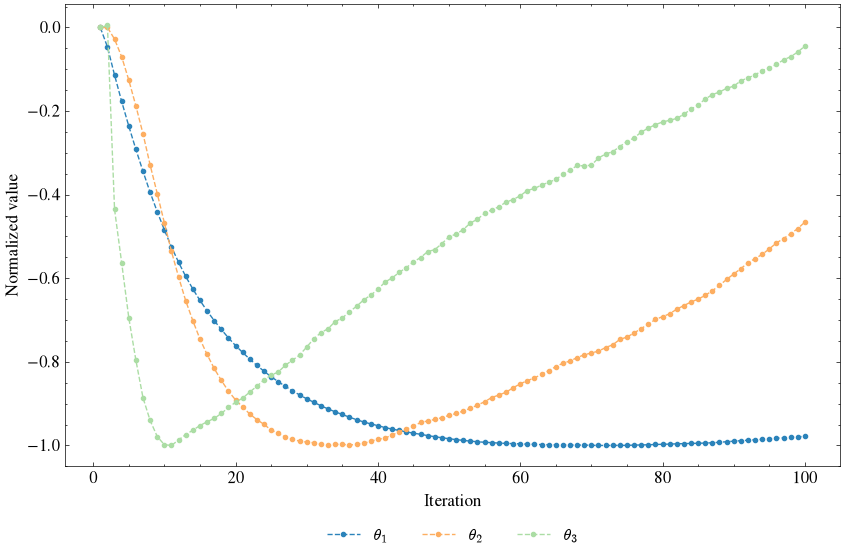

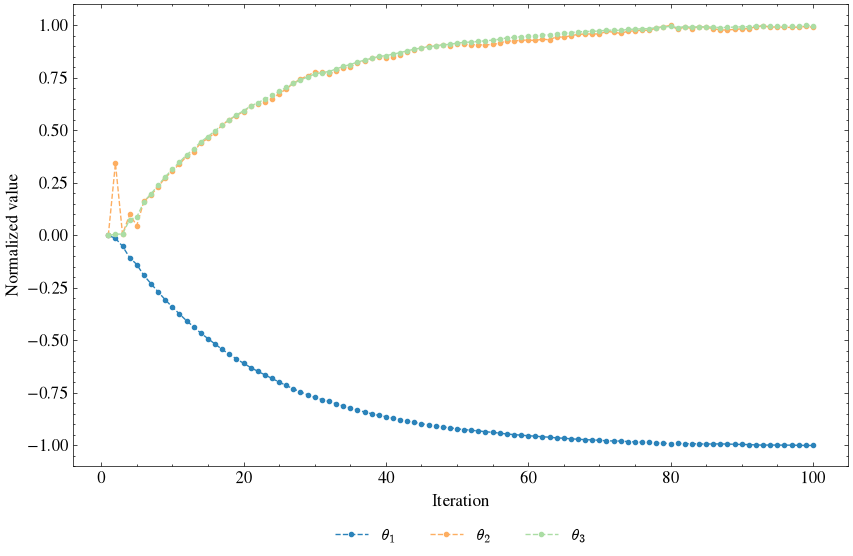

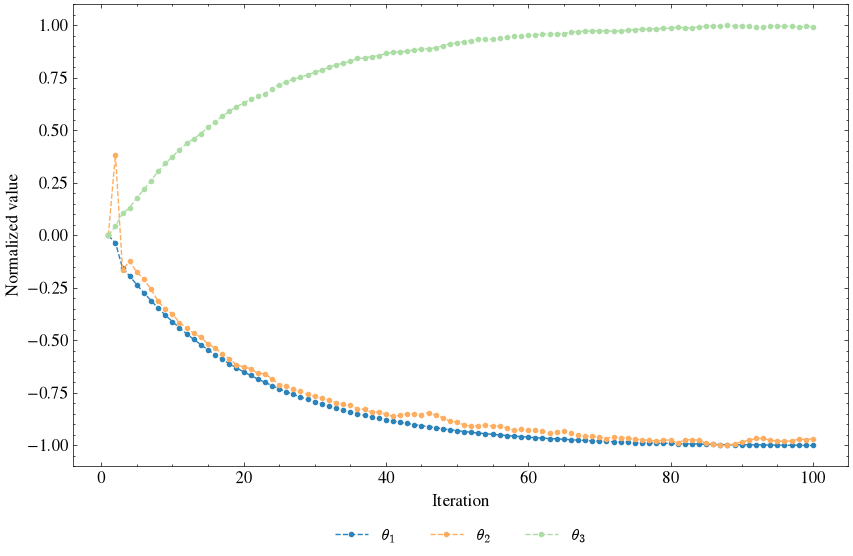

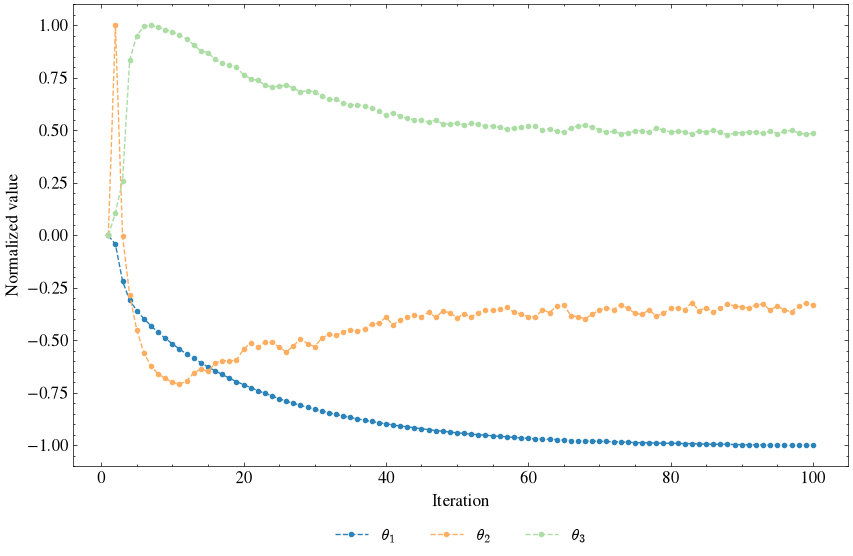

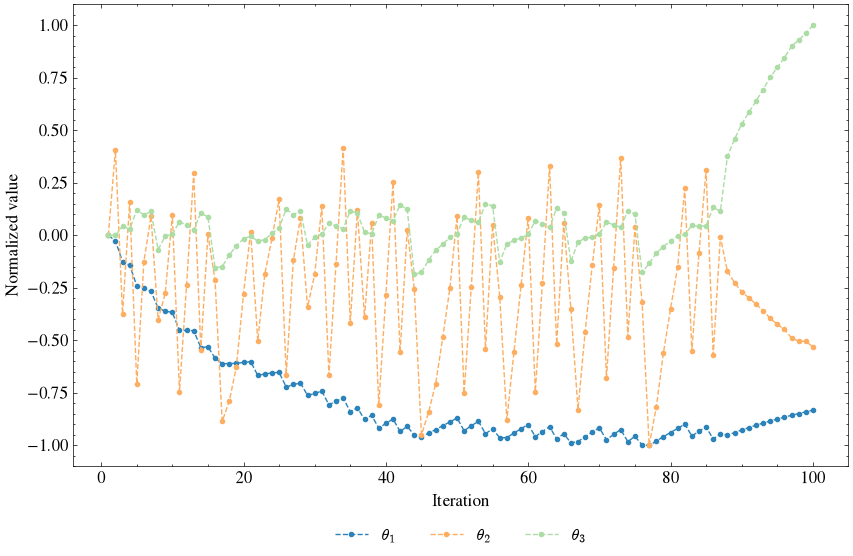

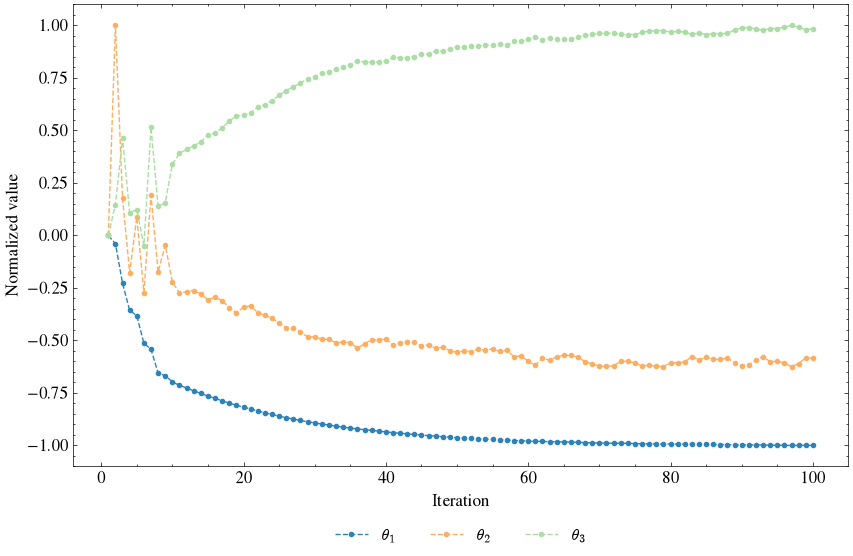

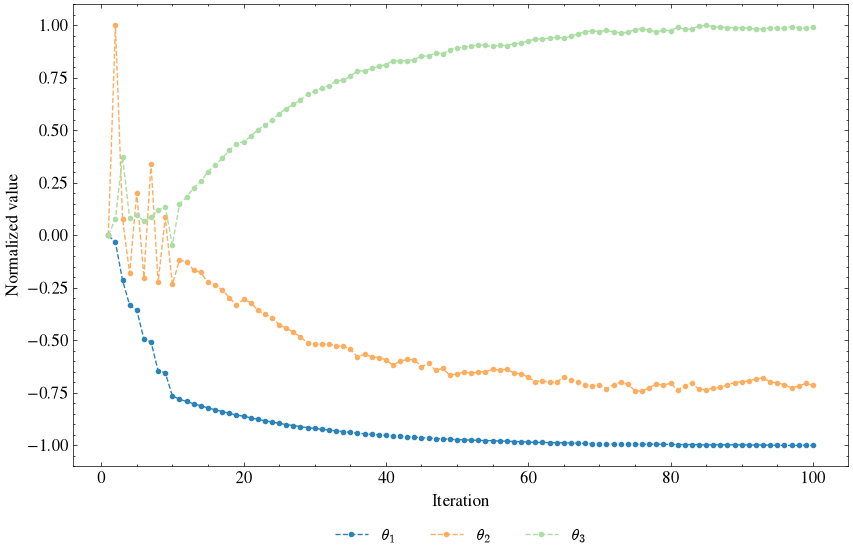

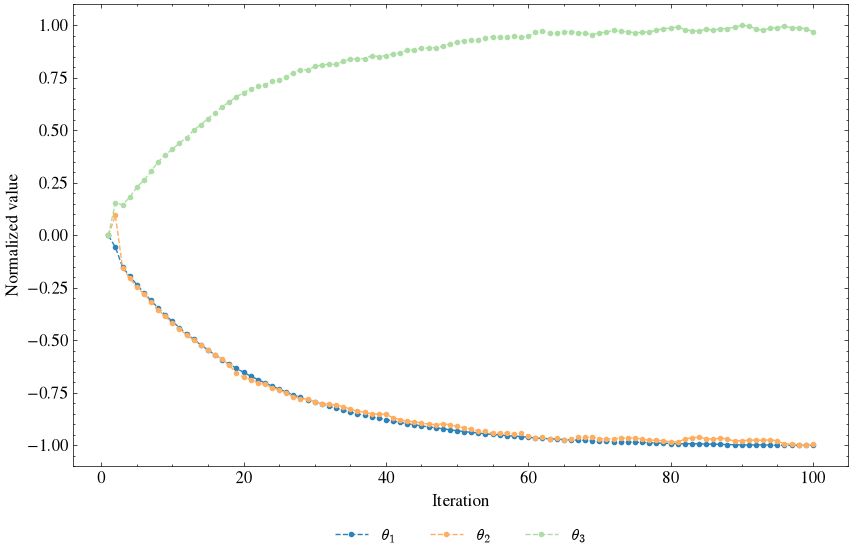

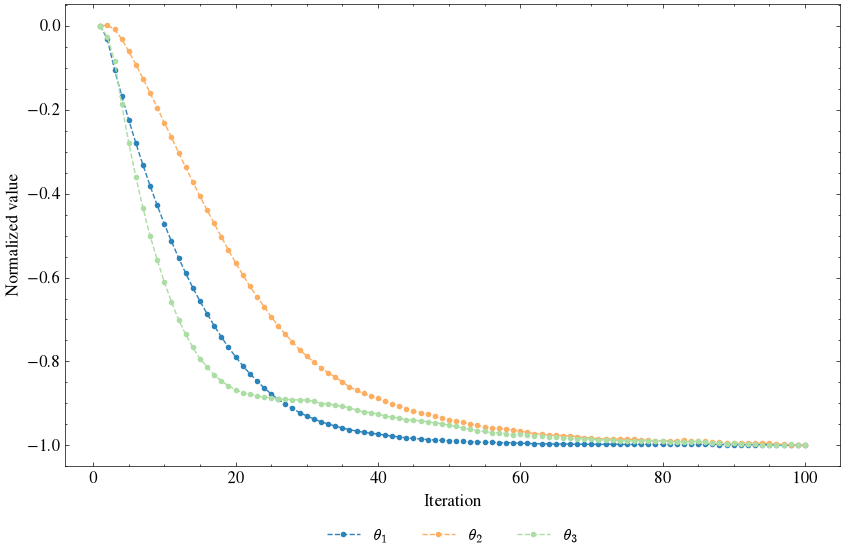

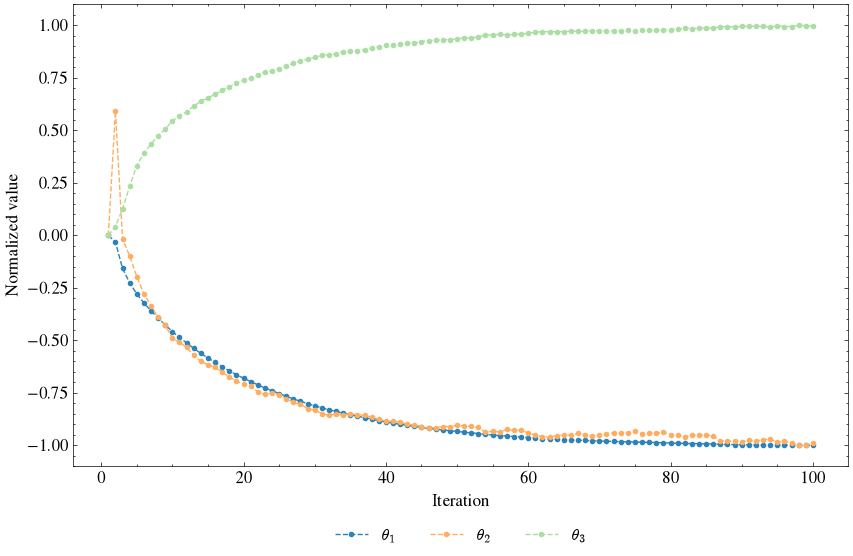

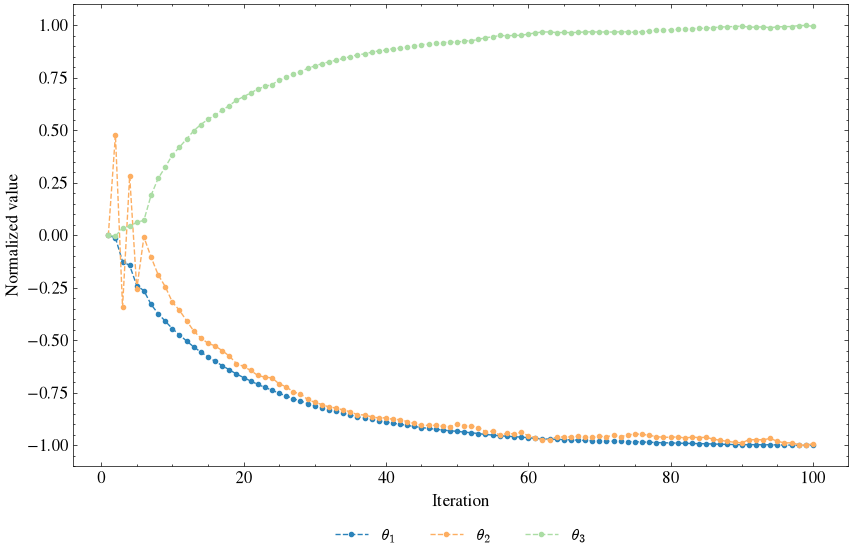

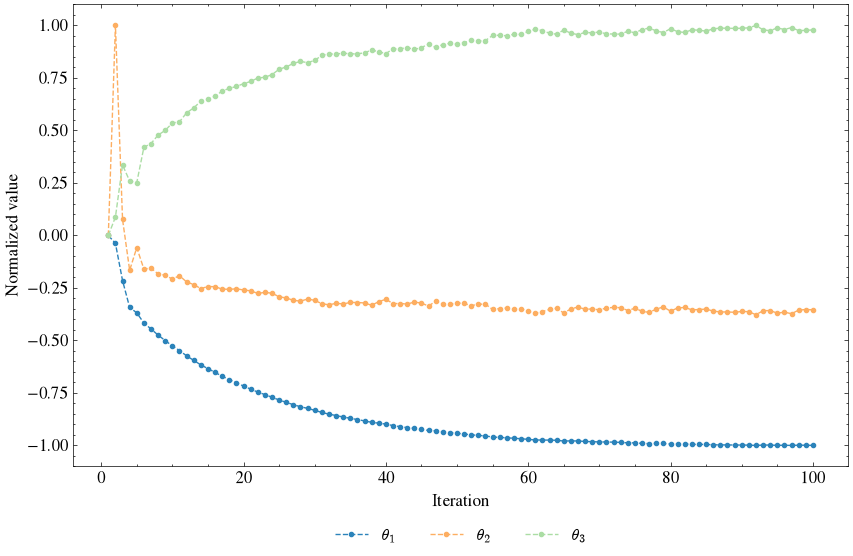

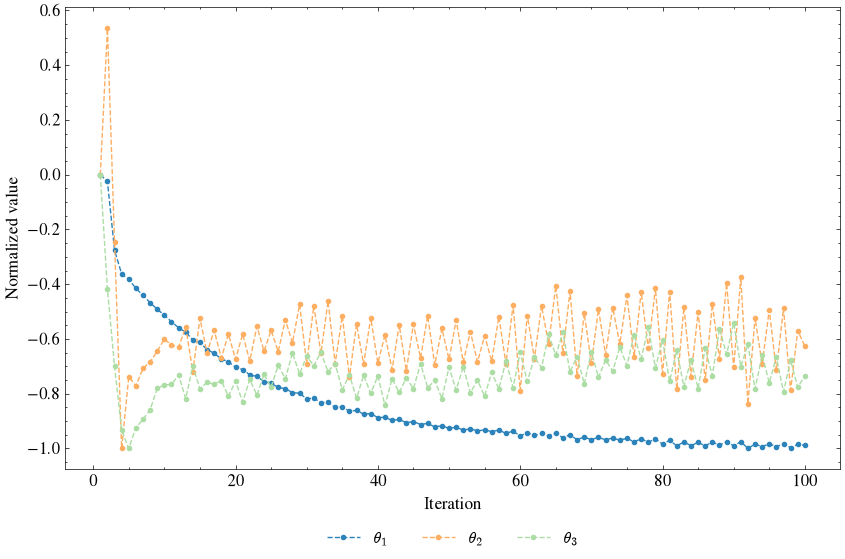

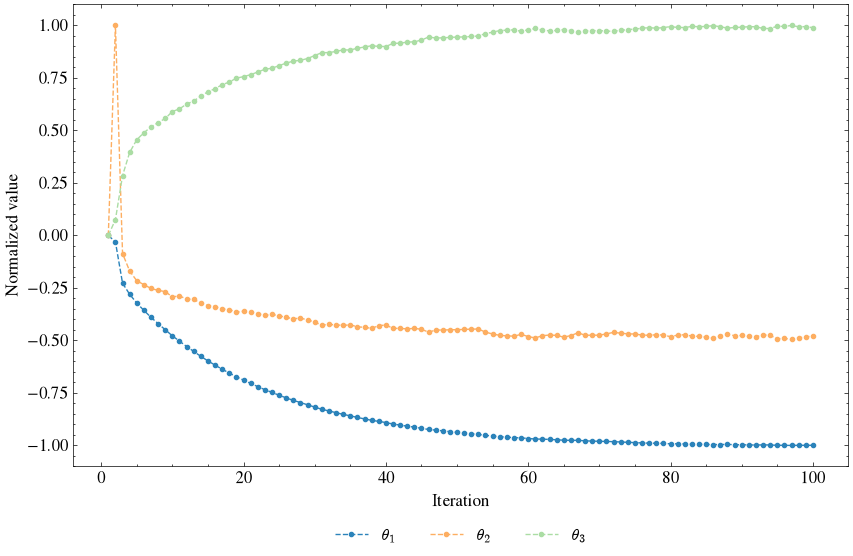

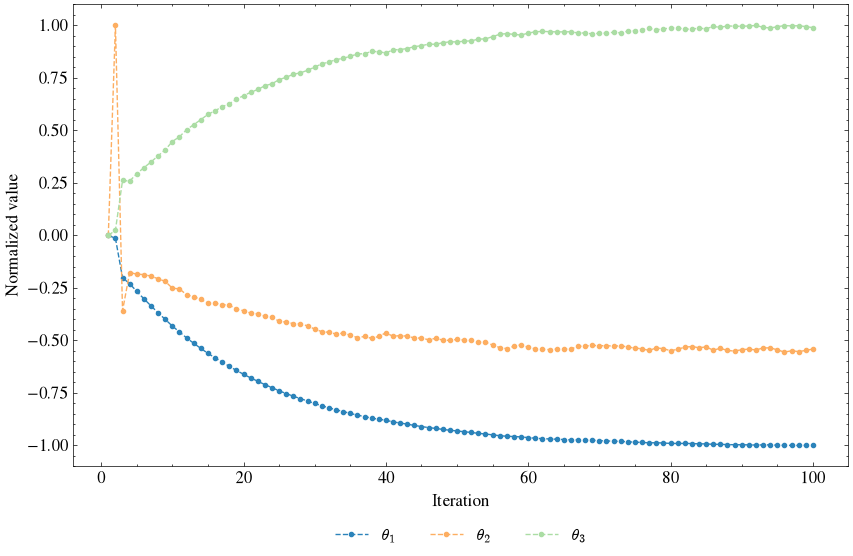

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def lspi_plot(num_warehouses, num_customers, capacity_distribution, normalize=False, show_theta_convergence=False, show_reward= False):

    plt.figure(figsize=(10, 6))

    data = pd.read_csv(f'training/least_squares_policy_iteration_training/lspi_evolution_w_{num_warehouses}_c_{num_customers}_d_{capacity_distribution}.csv')

    if show_reward:
        mean_reward = data['mean_reward']
        if normalize:
            first_reward = mean_reward.iloc[0]
            last_reward = mean_reward.iloc[-1]
            denom = last_reward - first_reward
            if np.isclose(denom, 0):
                mean_reward = mean_reward - first_reward
            else:
                mean_reward = (mean_reward - first_reward) / denom

        # Plot the data - mean_reward stays a fixed neutral color so it visually stands
        # apart from the colormap-colored theta coefficient lines below.
        plt.plot(data['iteration'], mean_reward, marker='o', linestyle='-', color='black', label='Mean reward')

    if show_theta_convergence:
        # theta is stored as a comma-joined string per iteration; parse into an (iterations x coefficients) matrix
        theta_matrix = np.array([list(map(float, row.split(','))) for row in data['theta']])
        # normalize each coefficient by its own max absolute value across iterations, not by
        # the first iteration - theta starts at np.zeros() and is logged before the first
        # update in update_policy, so the first row is always all zeros and would divide by zero
        max_abs = np.max(np.abs(theta_matrix), axis=0)
        max_abs[max_abs == 0] = 1  # avoid dividing a coefficient that stays at 0 throughout
        normalized_theta = theta_matrix / max_abs

        theta_colors = get_colors(normalized_theta.shape[1])
        for coef_idx in range(normalized_theta.shape[1]):
            plt.plot(
                data['iteration'],
                normalized_theta[:, coef_idx],
                marker='.',
                linestyle='--',
                color=theta_colors[coef_idx],
                label=rf'$\theta_{{{coef_idx + 1}}}$'
            )

    plt.xlabel('Iteration', fontsize=FONT_SIZE_LABEL)
    plt.ylabel('Normalized value' if (normalize or show_theta_convergence) else 'Mean Reward', fontsize=FONT_SIZE_LABEL)
    plt.xticks(fontsize=FONT_SIZE_TICK)
    plt.yticks(fontsize=FONT_SIZE_TICK)
    if normalize or show_theta_convergence:
        plt.legend(fontsize=FONT_SIZE_LEGEND, loc='upper center', bbox_to_anchor=(0.5, -0.10), ncol=4)
    #plt.title('Mean Reward over Iterations')
    plt.grid(False)

    # Save the plot
    plt.savefig(f'training/least_squares_policy_iteration_training/plots/lspi_evolution_w_{num_warehouses}_c_{num_customers}_{capacity_distribution}.pdf', dpi=600, bbox_inches='tight')

    #plt.show()

num_warehouses_options = [2, 3, 4, 5]
num_customers_options = [50, 100, 200, 400]
capacity_distribution_options = ['uniform', 'uneven']

for num_customers in num_customers_options:
    for num_warehouses in num_warehouses_options:
        for capacity_distribution in capacity_distribution_options:
            #print(f"Plotting LSPI for {num_warehouses} warehouses, {num_customers} customers, {capacity_distribution} distribution")
            lspi_plot(num_warehouses, num_customers, capacity_distribution, normalize=True, show_theta_convergence=True)

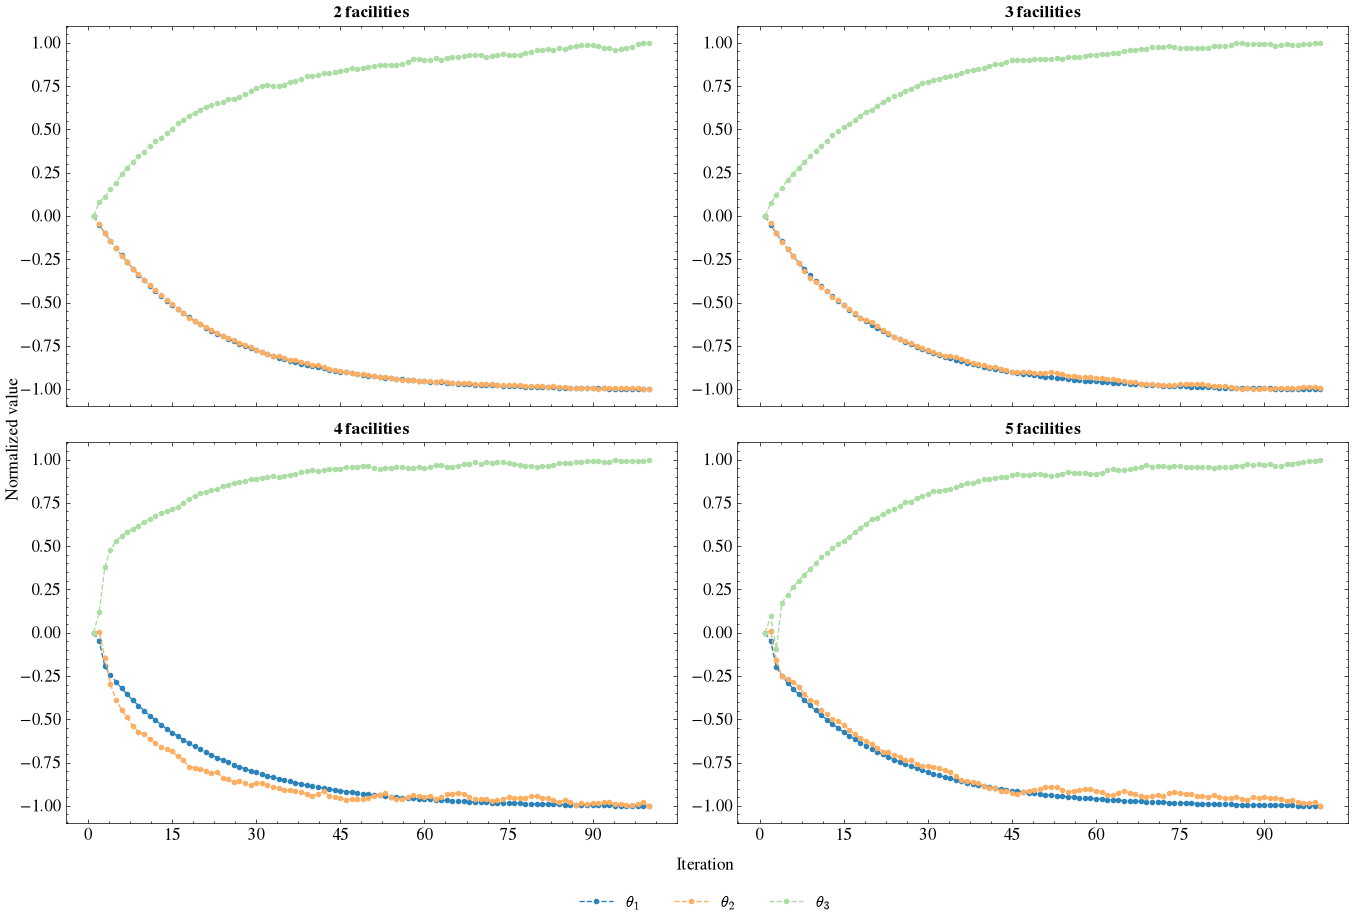

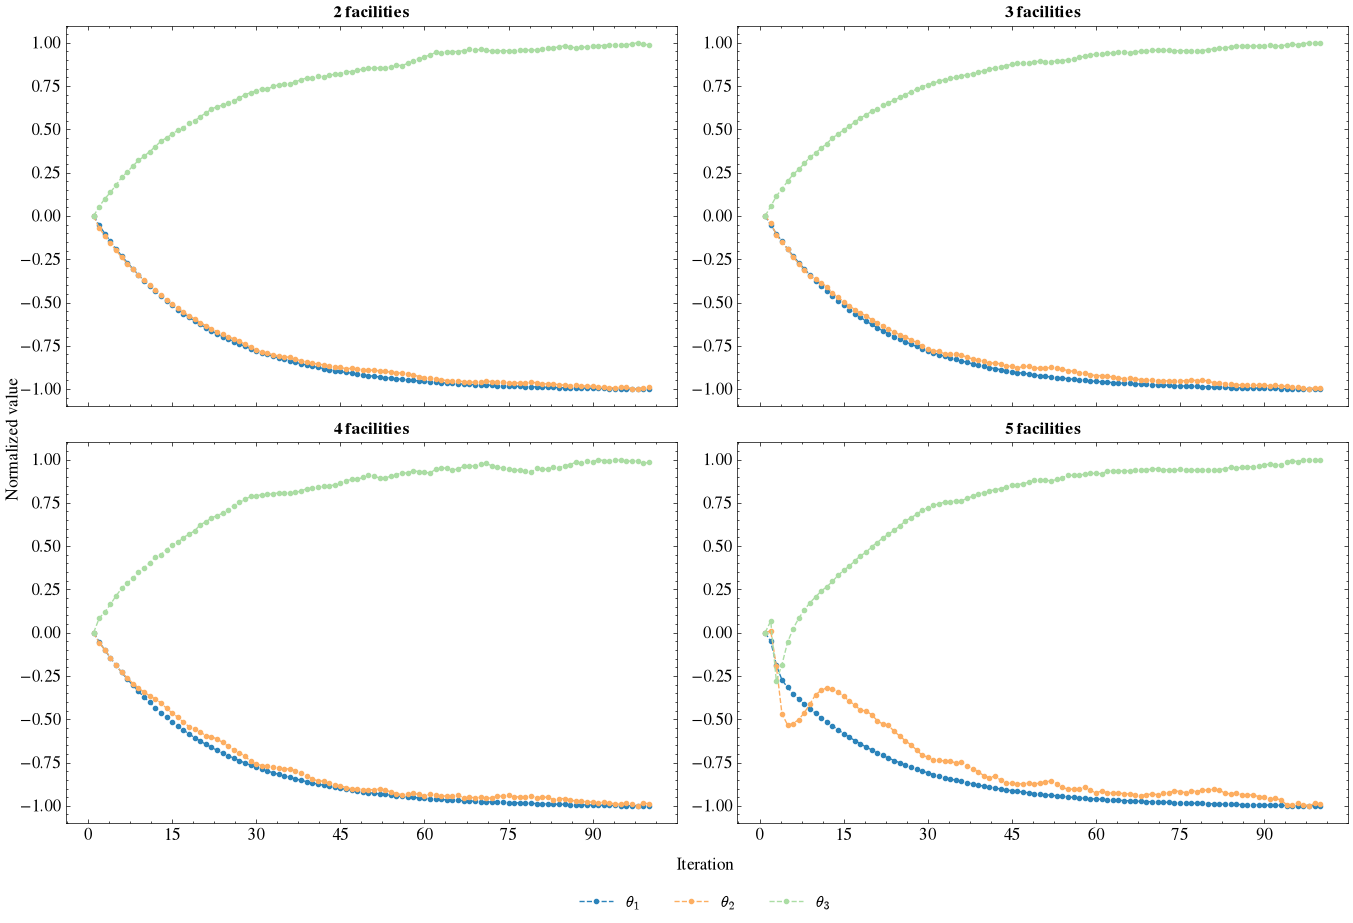

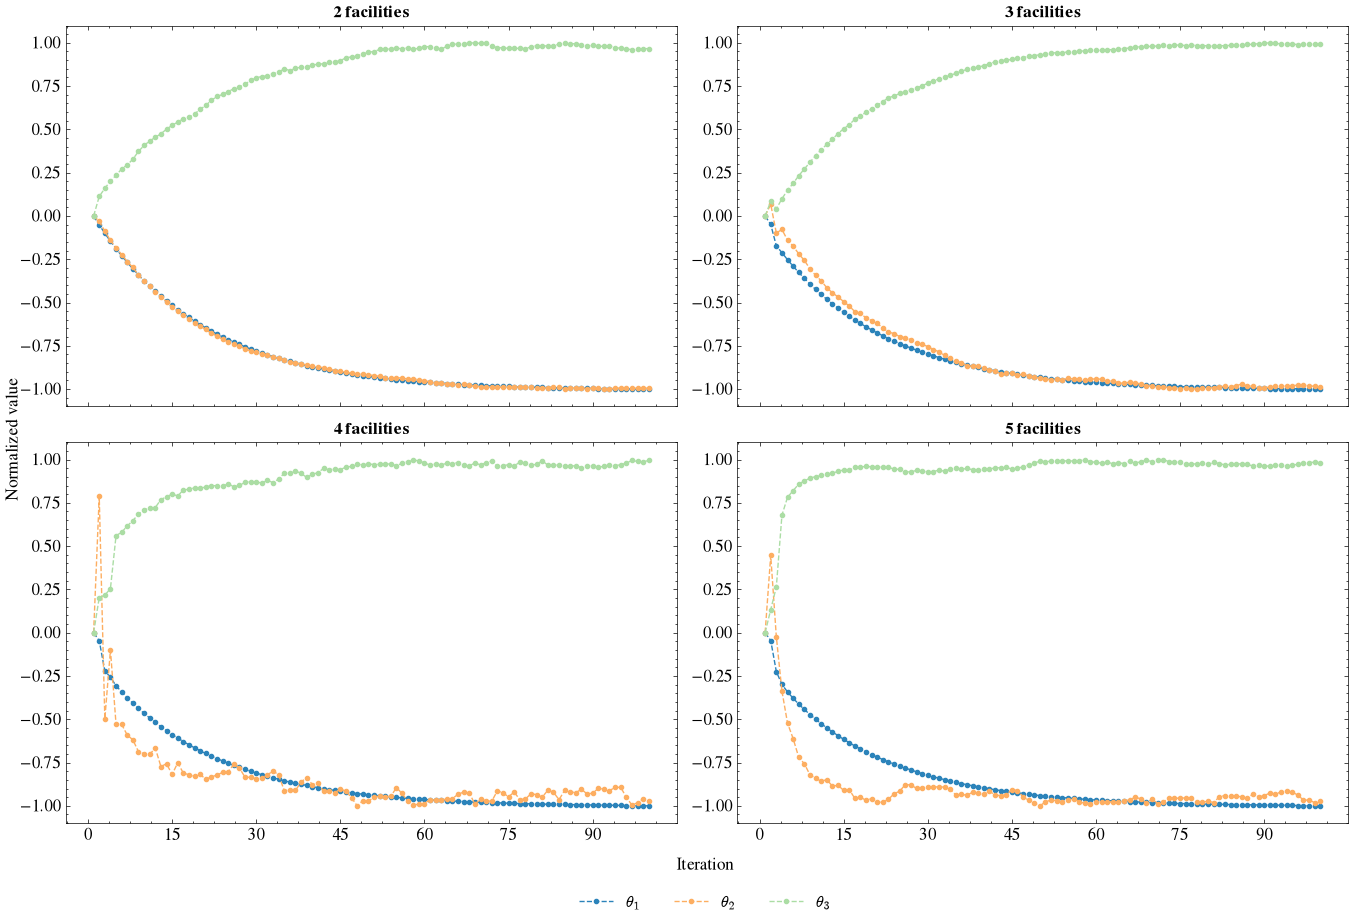

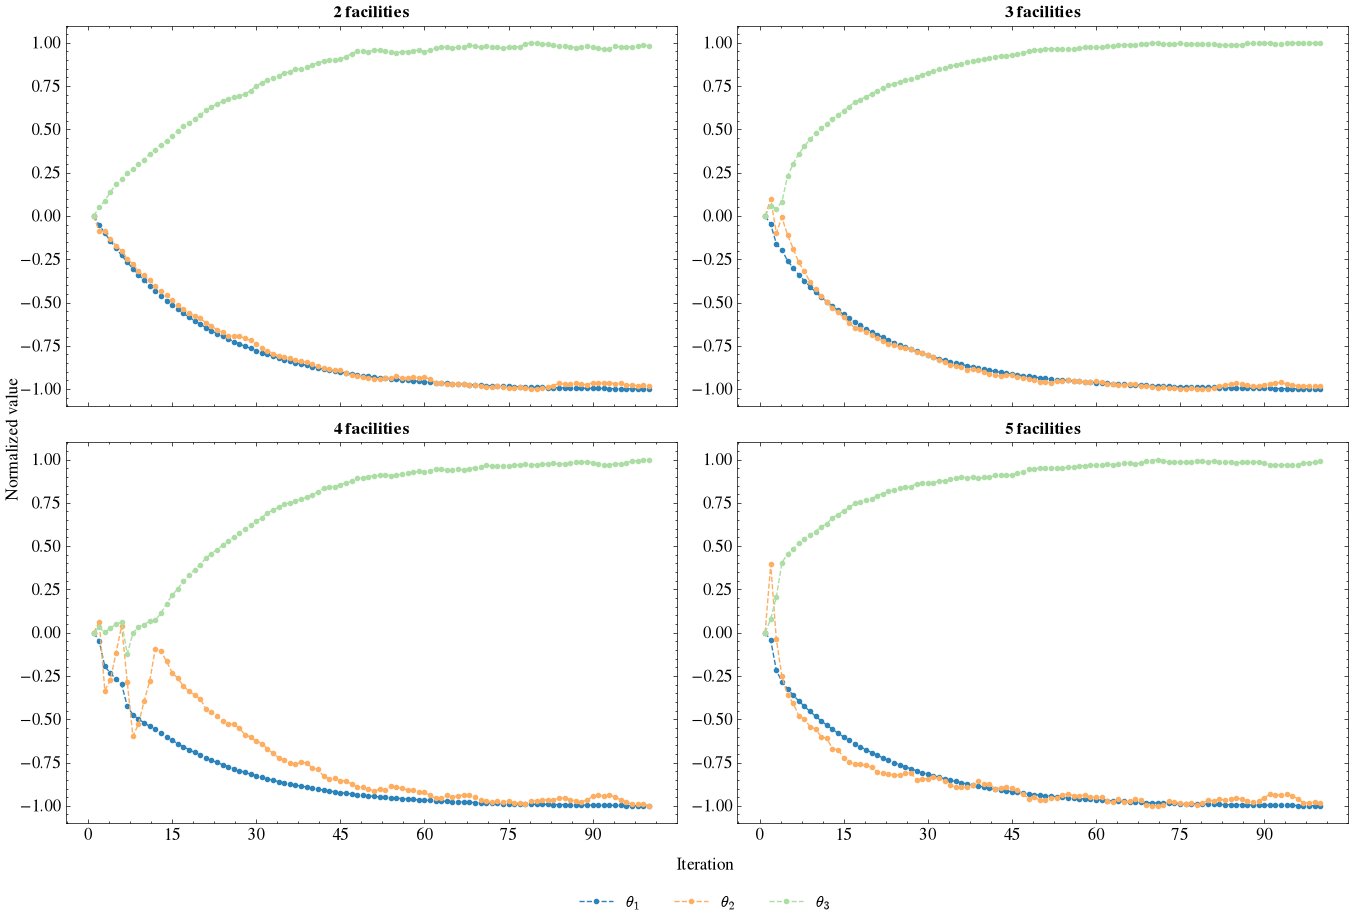

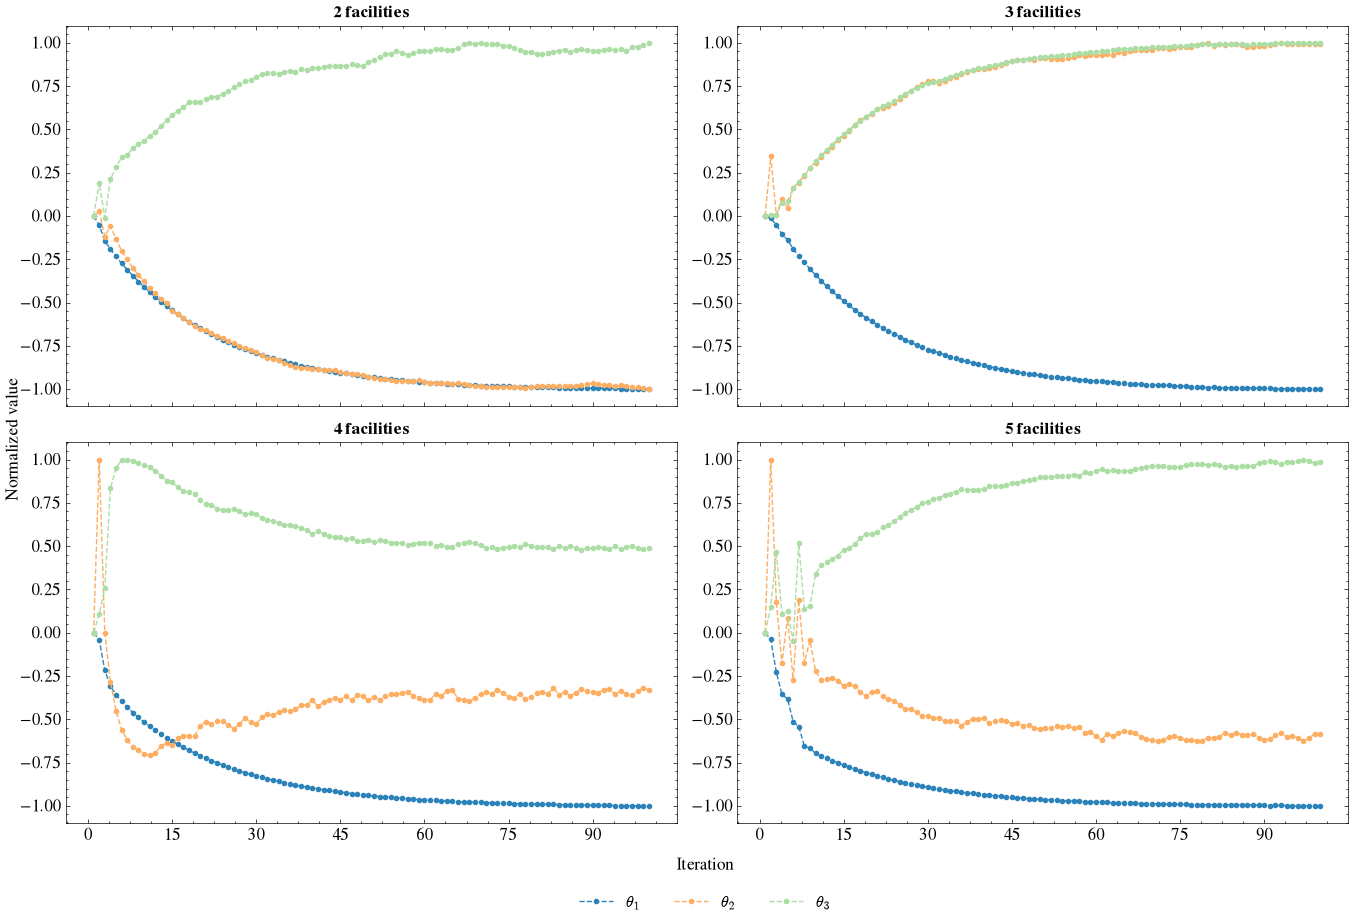

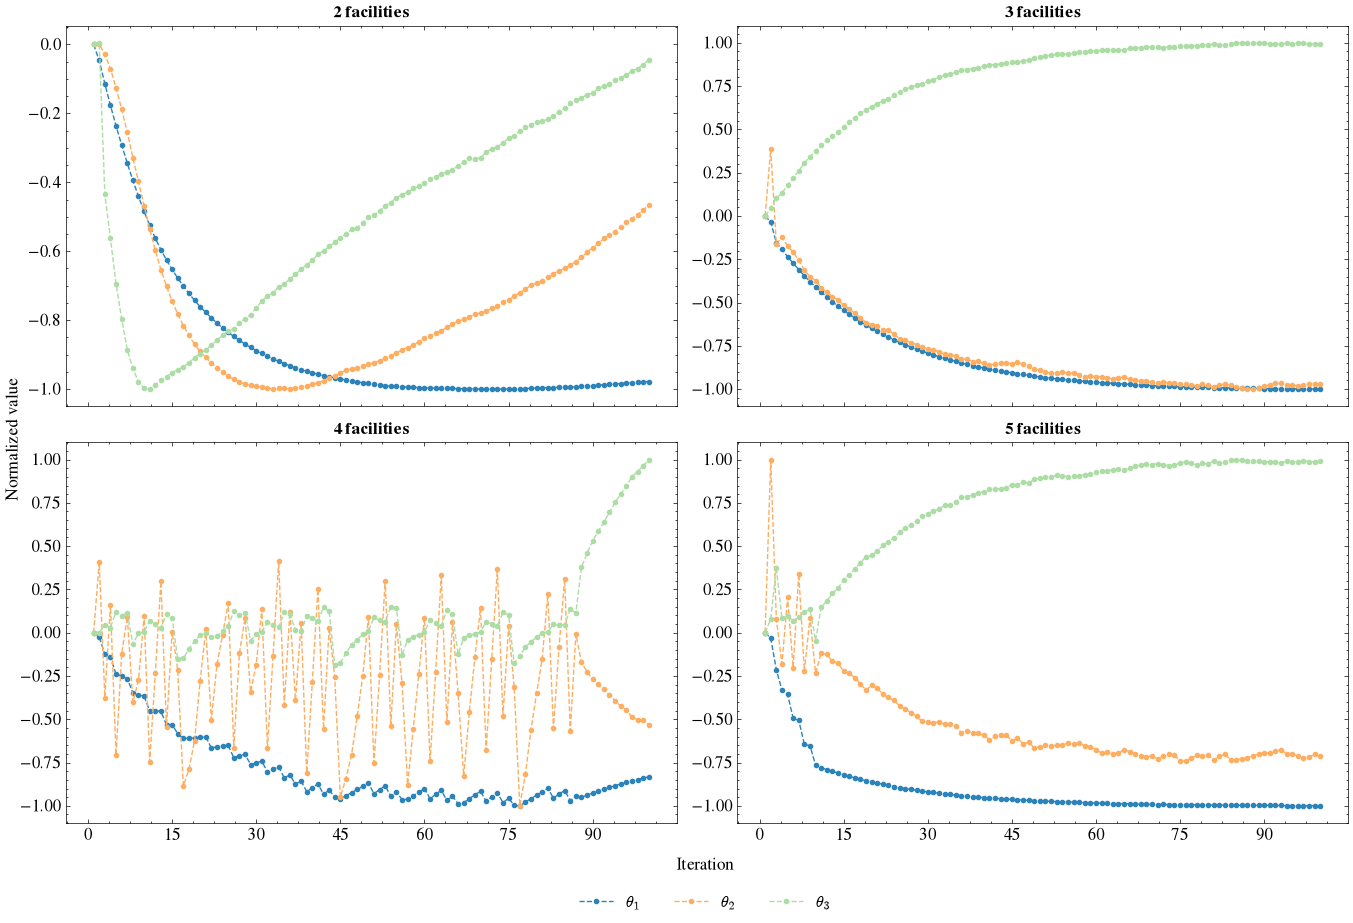

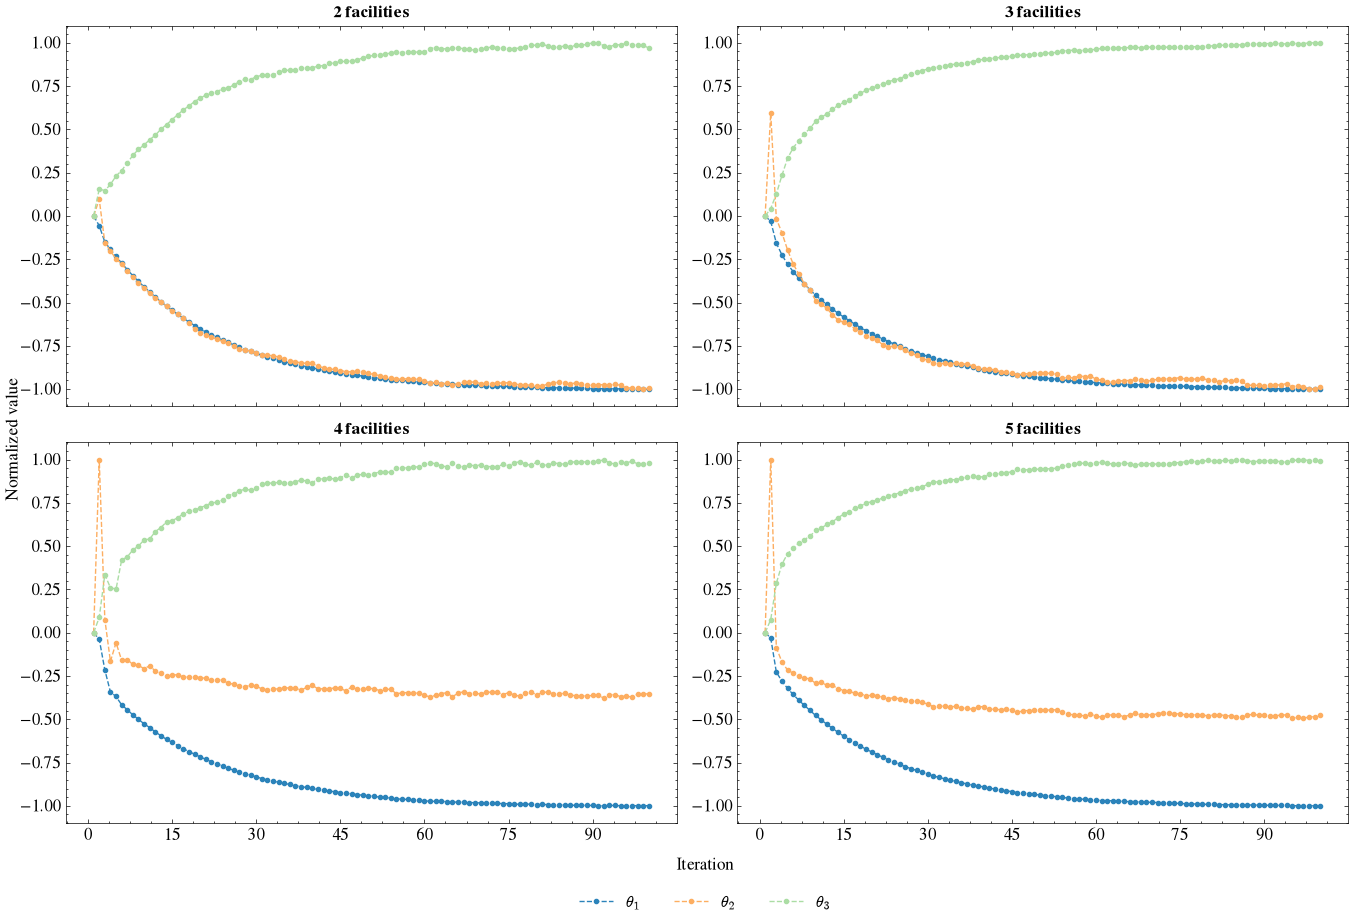

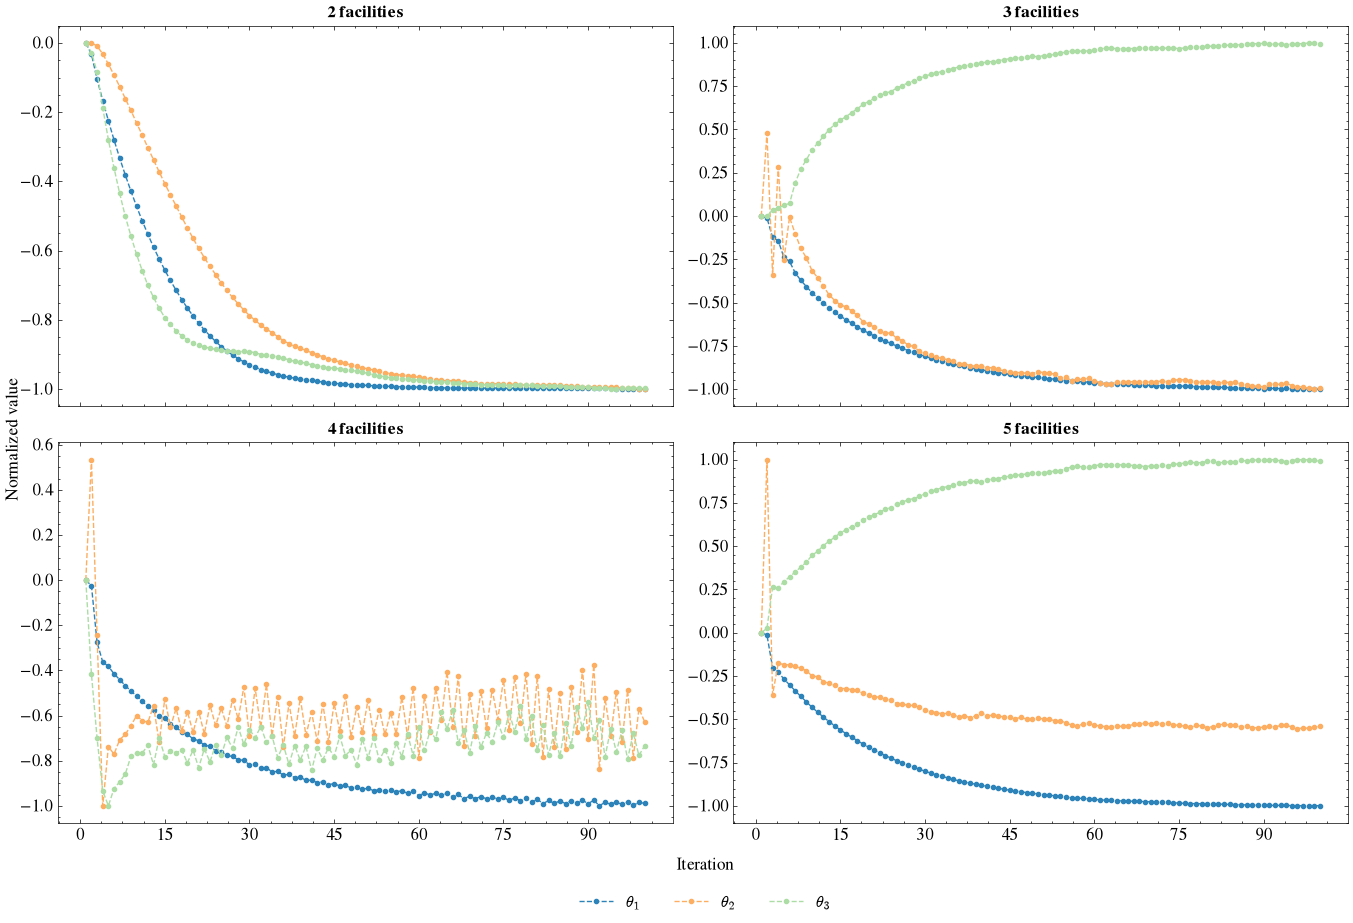

In [8]:
# Aggregate LSPI plots into 2x2 grids: one figure per (num_customers, capacity_distribution),
# subplots = num_warehouses_options (2,3,4,5)
def _plot_lspi_on_ax(ax, num_warehouses, num_customers, capacity_distribution, normalize=False, show_theta_convergence=False, show_reward=False):
    data = pd.read_csv(f'training/least_squares_policy_iteration_training/lspi_evolution_w_{num_warehouses}_c_{num_customers}_d_{capacity_distribution}.csv')
    if show_reward:
        mean_reward = data['mean_reward']
        if normalize:
            first_reward = mean_reward.iloc[0]
            last_reward = mean_reward.iloc[-1]
            denom = last_reward - first_reward
            if np.isclose(denom, 0):
                mean_reward = mean_reward - first_reward
            else:
                mean_reward = (mean_reward - first_reward) / denom
        ax.plot(data['iteration'], mean_reward, marker='o', linestyle='-', color='black', label='Mean reward')

    if show_theta_convergence:
        theta_matrix = np.array([list(map(float, row.split(','))) for row in data['theta']])
        max_abs = np.max(np.abs(theta_matrix), axis=0)
        max_abs[max_abs == 0] = 1
        normalized_theta = theta_matrix / max_abs
        theta_colors = get_colors(normalized_theta.shape[1])
        for coef_idx in range(normalized_theta.shape[1]):
            ax.plot(
                data['iteration'],
                normalized_theta[:, coef_idx],
                marker='.',
                linestyle='--',
                color=theta_colors[coef_idx],
                label=rf'$\theta_{{{coef_idx + 1}}}$'
            )
    ax.set_title(f'{num_warehouses} facilities', fontsize=TITLE_FONT_SIZE)
    #Make title bold
    ax.title.set_fontweight('bold')
    ax.grid(False)
    ax.tick_params(axis='both', labelsize=FONT_SIZE_TICK)
    ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))

num_warehouses_options = [2, 3, 4, 5]
num_customers_options = [50, 100, 200, 400]
capacity_distribution_options = ['uniform', 'uneven']

for num_customers in num_customers_options:
    for capacity_distribution in capacity_distribution_options:
        fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharex=True, sharey=False)
        axes = np.atleast_1d(axes).flatten()
        for ax, num_warehouses in zip(axes, num_warehouses_options):
            _plot_lspi_on_ax(ax, num_warehouses, num_customers, capacity_distribution, normalize=True, show_theta_convergence=True, show_reward=False)

        # common labels
        fig.text(0.53, 0.07, 'Iteration', ha='center', fontsize=FONT_SIZE_LABEL)
        fig.text(0.03, 0.5, 'Normalized value', va='center', rotation='vertical', fontsize=FONT_SIZE_LABEL)

        # combined legend: gather handles/labels from all subplots and deduplicate by label order-preserving
        handles_labels = [ax.get_legend_handles_labels() for ax in axes]
        all_handles = sum([hl[0] for hl in handles_labels], [])
        all_labels = sum([hl[1] for hl in handles_labels], [])
        unique = {}
        unique_handles = []
        unique_labels = []
        for h, l in zip(all_handles, all_labels):
            if l not in unique:
                unique[l] = True
                unique_handles.append(h)
                unique_labels.append(l)

        if unique_handles:
            fig.legend(unique_handles, unique_labels, loc='upper center', bbox_to_anchor=(0.53, 0.06), ncol=min(6, len(unique_labels)), fontsize=FONT_SIZE_LEGEND)

        plt.tight_layout(rect=[0.03, 0.08, 1, 0.95])
        out_dir = 'training/least_squares_policy_iteration_training/plots'
        os.makedirs(out_dir, exist_ok=True)
        plt.savefig(f'{out_dir}/lspi_evolution_c_{num_customers}_d_{capacity_distribution}.pdf', dpi=600, bbox_inches='tight')
        #plt.show()

'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


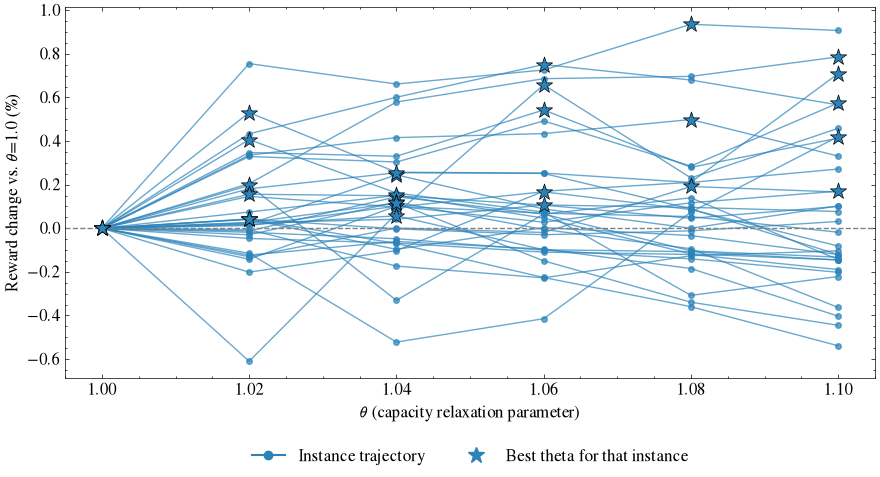

In [15]:
# PLA (parameterized lookahead approximation) sensitivity to theta, across every
# instance in the tuning dataset. Raw mean_reward magnitudes aren't comparable across
# instance sizes, so each instance's curve is normalized against its own theta=1.0
# value (the unparameterized DEL policy - see Eq. 23) before plotting them together.
# Maximization framing: higher (more positive) = better, mirroring the standard RL
# reward-maximization view. No color coding by instance dimension - every instance gets the
# same line color, distinguished only by its trajectory and its own best-theta marker.
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

theta_df = pd.read_csv('training/parameterized_lookahead_approximation_training/parameterized_lookahead_approximation_all_params.csv')

# reward is negative total distance (Eq. 9) - normalize directly against |baseline|
# so a positive pct always means reward improved (baseline itself is negative).

instance_cols = ['num_warehouses', 'num_customers', 'capacity_distribution']

baseline_reward = theta_df.loc[theta_df['param'] == 1.0].set_index(instance_cols)['mean_reward']
theta_df = theta_df.join(baseline_reward.rename('baseline_reward'), on=instance_cols)
# maximization: positive means theta increased reward vs. theta=1.0, negative means it decreased it
theta_df['normalized_pct'] = 100 * (theta_df['mean_reward'] - theta_df['baseline_reward']) / theta_df['baseline_reward'].abs()

instances = theta_df[instance_cols].drop_duplicates().sort_values(instance_cols).to_records(index=False).tolist()

INSTANCE_COLOR = get_colors(1)[0]  # single color for every instance - no per-dimension color coding

fig, ax = plt.subplots(figsize=(9, 5))

for inst in instances:
    num_warehouses, num_customers, capacity_distribution = inst
    inst_data = theta_df[
        (theta_df['num_warehouses'] == num_warehouses)
        & (theta_df['num_customers'] == num_customers)
        & (theta_df['capacity_distribution'] == capacity_distribution)
    ].sort_values('param')

    ax.plot(
        inst_data['param'],
        inst_data['normalized_pct'],
        marker='o',
        markersize=4,
        linewidth=1,
        alpha=0.7,
        color=INSTANCE_COLOR,
    )

    best_row = inst_data.loc[inst_data['normalized_pct'].idxmax()]  # maximization: best = highest (most positive)
    ax.scatter(
        best_row['param'],
        best_row['normalized_pct'],
        marker='*',
        s=150,
        color=INSTANCE_COLOR,
        edgecolor='black',
        linewidth=0.5,
        zorder=5,
    )

ax.axhline(0, color='gray', linewidth=1, linestyle='--')
ax.set_xlabel(r'$\theta$ (capacity relaxation parameter)', fontsize=FONT_SIZE_LABEL)
ax.set_ylabel(r'Reward change vs. $\theta$=1.0 (%)', fontsize=FONT_SIZE_LABEL)
ax.tick_params(axis='both', labelsize=FONT_SIZE_TICK)
#ax.set_title('PLA sensitivity to theta across instances')

legend_elements = [
    Line2D([0], [0], color=INSTANCE_COLOR, marker='o', markersize=6, linewidth=1.5, label='Instance trajectory'),
    Line2D([0], [0], color=INSTANCE_COLOR, marker='*', markersize=12, linestyle='None', label='Best theta for that instance'),
]
ax.legend(handles=legend_elements, loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=2, fontsize=FONT_SIZE_LEGEND)
plt.tight_layout()
plt.savefig('training/parameterized_lookahead_approximation_training/plots/pla_theta_sensitivity_across_instances.pdf', dpi=600, bbox_inches='tight')
#plt.show()